# 02 Exploratory data analysis

#### \#\#\# *Characterising neighbourhoods* \#\#\#

This notebook is for research question-specific EDA.

**Research questions:**

1. How do neighbourhoods in Copenhagen and Frederiksberg cluster based on demographic and socioeconomic characteristics?
2. What distinguishes these clusters?
3. How can outliers, if they exist, be explained? 

**Notes:**

For this research question, we only focus on 2021 data, as this is the year with the newest demographics data, and we want the election data from the same year as the demoographics data.

*Author: loua*

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.manifold import TSNE


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option("display.max_colwidth", None)

In [2]:
ROOT = '../../'
INPUT_PATH = ROOT + 'processed-data/characterising-neighbourhoods/01_preprocessed.csv'
OUTPUT_PATH = ROOT + 'processed-data/characterising-neighbourhoods/02_afterEDA.csv'

## Load data

In [3]:
df = pd.read_csv(INPUT_PATH, dtype={'PollingAreaID': str})
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 58 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   PollingAreaID                                                 61 non-null     object 
 1   PollingArea                                                   61 non-null     object 
 2   Sex_Female                                                    61 non-null     float64
 3   Age_70- years                                                 61 non-null     float64
 4   Age_0-17 years                                                61 non-null     float64
 5   Age_18-29 years                                               61 non-null     float64
 6   Age_30-69 years                                               61 non-null     float64
 7   Education_18-29 years_Long higher education                   61 non-null

In [4]:
id_cols = ['PollingAreaID','PollingArea']
polling_areas = df[id_cols]
df_num = df.drop(columns=id_cols)

## Summary statistics and YData report

In [5]:
df.describe()

,Sex_Female,Age_70- years,Age_0-17 years,Age_18-29 years,Age_30-69 years,Education_18-29 years_Long higher education,Education_18-29 years_Primary and lower secondary,Education_18-29 years_Vocational training,Education_30-70+ years_Long higher education,Education_30-70+ years_Primary and lower secondary,Education_30-70+ years_Vocational training,Income_Gross income top20pct,Income_Median household income,Socioeconomy_Self-employed,Socioeconomy_Top executives,Socioeconomy_Unemployed,Benefit type_Foertidspension,Benefit type_Kontanthjaelp,Benefit type_Modtager ikke ydelser,Housing type_People_Apartment buildings,Housing type_People_Detached house,Housing type_People_Terraced house,Housing tenure_People_Almen,Housing tenure_People_Andel,Housing tenure_People_Ejer,Housing tenure_People_Private rental,Year built_People_1960-2009,Year built_People_2010-9999,Year built_People_Before 1960,Car_Households with no car,Crime_Number of arrests,Immigrants_Other Europe,Immigrants_Western,Immigrants_Eastern Europe,Immigrants_Global South,Citizenship_Denmark,Citizenship_Other Europe,Citizenship_Western,Citizenship_Eastern Europe,Citizenship_Global South,Voter turnout,Vote share_Blank votes,Vote share_Alternativet,Vote share_Dansk Folkeparti,Vote share_Det Konservative Folkeparti,Vote share_Enhedslisten - De Rød-Grønne,Vote share_Frihedslisten,Vote share_Kristendemokraterne,Vote share_Kærlighedspartiet Regnbuefolket Befri Christiania,Vote share_Liberal Alliance,Vote share_Nye Borgerlige,Vote share_Radikale Venstre,Vote share_SF - Socialistisk Folkeparti,Vote share_Socialdemokratiet,Vote share_Veganerpartiet,Vote share_Venstre Danmarks Liberale Parti
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,6.100000e+01,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,50.905446,8.027846,17.834624,24.913380,49.224150,8.624227,4.263068,2.073561,21.692583,10.955706,14.436106,2.767267e+07,476946.803279,3.165847,1.879756,2.988496,2.598302,2.718457,68.850639,85.606588,7.362856,4.274130,23.036644,36.834447,29.592392,10.536518,19.157066,6.543661,74.299273,59.909295,0.552948,2.538449,34.720116,15.729091,46.917013,83.455956,0.329012,7.623528,2.873907,5.612036,62.073584,1.384464,2.577492,1.876463,16.249561,23.854923,0.354815,0.371518,0.144178,2.418737,1.965498,11.382506,10.277461,17.865766,0.560827,7.157356
std,1.476550,3.389102,3.240658,5.812480,2.763140,3.026920,1.218511,0.782920,6.158011,4.050529,3.682277,7.421086e+06,89980.567253,0.853955,0.851950,0.631353,1.231489,1.438878,4.384957,14.996092,11.013056,4.898888,18.284437,18.643084,16.797749,4.975974,13.539461,12.057071,20.527803,8.739688,0.427221,1.078048,14.442679,3.630260,13.360189,5.804899,0.183633,2.606465,1.803888,4.199290,8.553687,0.374798,1.046799,1.028596,10.438456,6.856753,0.135175,0.157311,0.073182,1.091434,0.789073,1.981671,2.584111,4.577255,0.183689,2.460070
min,46.191392,1.443536,10.854969,15.185497,42.644171,2.723334,2.377022,0.788791,8.985747,4.155103,8.485379,1.505687e+07,276421.000000,2.096273,0.217391,2.015563,0.664282,0.806452,57.777224,29.383527,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.968574,36.179261,0.163470,0.415800,3.364203,9.109069,22.689805,52.337005,0.139054,3.374119,0.792580,1.831252,33.266219,0.597745,0.656635,0.437756,5.281445,13.986728,0.123119,0.107596,0.013680,0.694927,0.557222,6.813020,3.798537,10.812731,0.157658,1.945796
25%,50.198855,5.886812,15.612127,20.957417,47.515667,6.220096,3.394433,1.465262,17.208413,8.551333,11.424080,2.365482e+07,409322.000000,2.582293,1.328727,2.479436,1.627319

The produced YData Profiling report can be found at `data-wrangling/characterising-neighbourhoods/ydata/characterising_neighbourhoods_dataset_report.html`:


In [6]:
# Uncomment to create YData report
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title="Characterising CPH and FRB neighbourhoods", explorative=True)
# profile.to_file("EDA/characterising_neighbourhoods_dataset_report.html")

The report shows that a lot of variables are highly correlated with each other.

## Correlation heatmaps

The heatmaps show the Pearson correlation coefficient between two columns.

Red / values close to 1 show high POSITIVE correlation: When the value in column X increases, the value in column Y also tends to increase.

Blue / values close to -1 show high NEGATIVE correlation: When the value in column X increases, the value in column Y tends to decrease.

### All vs all

<Axes: >

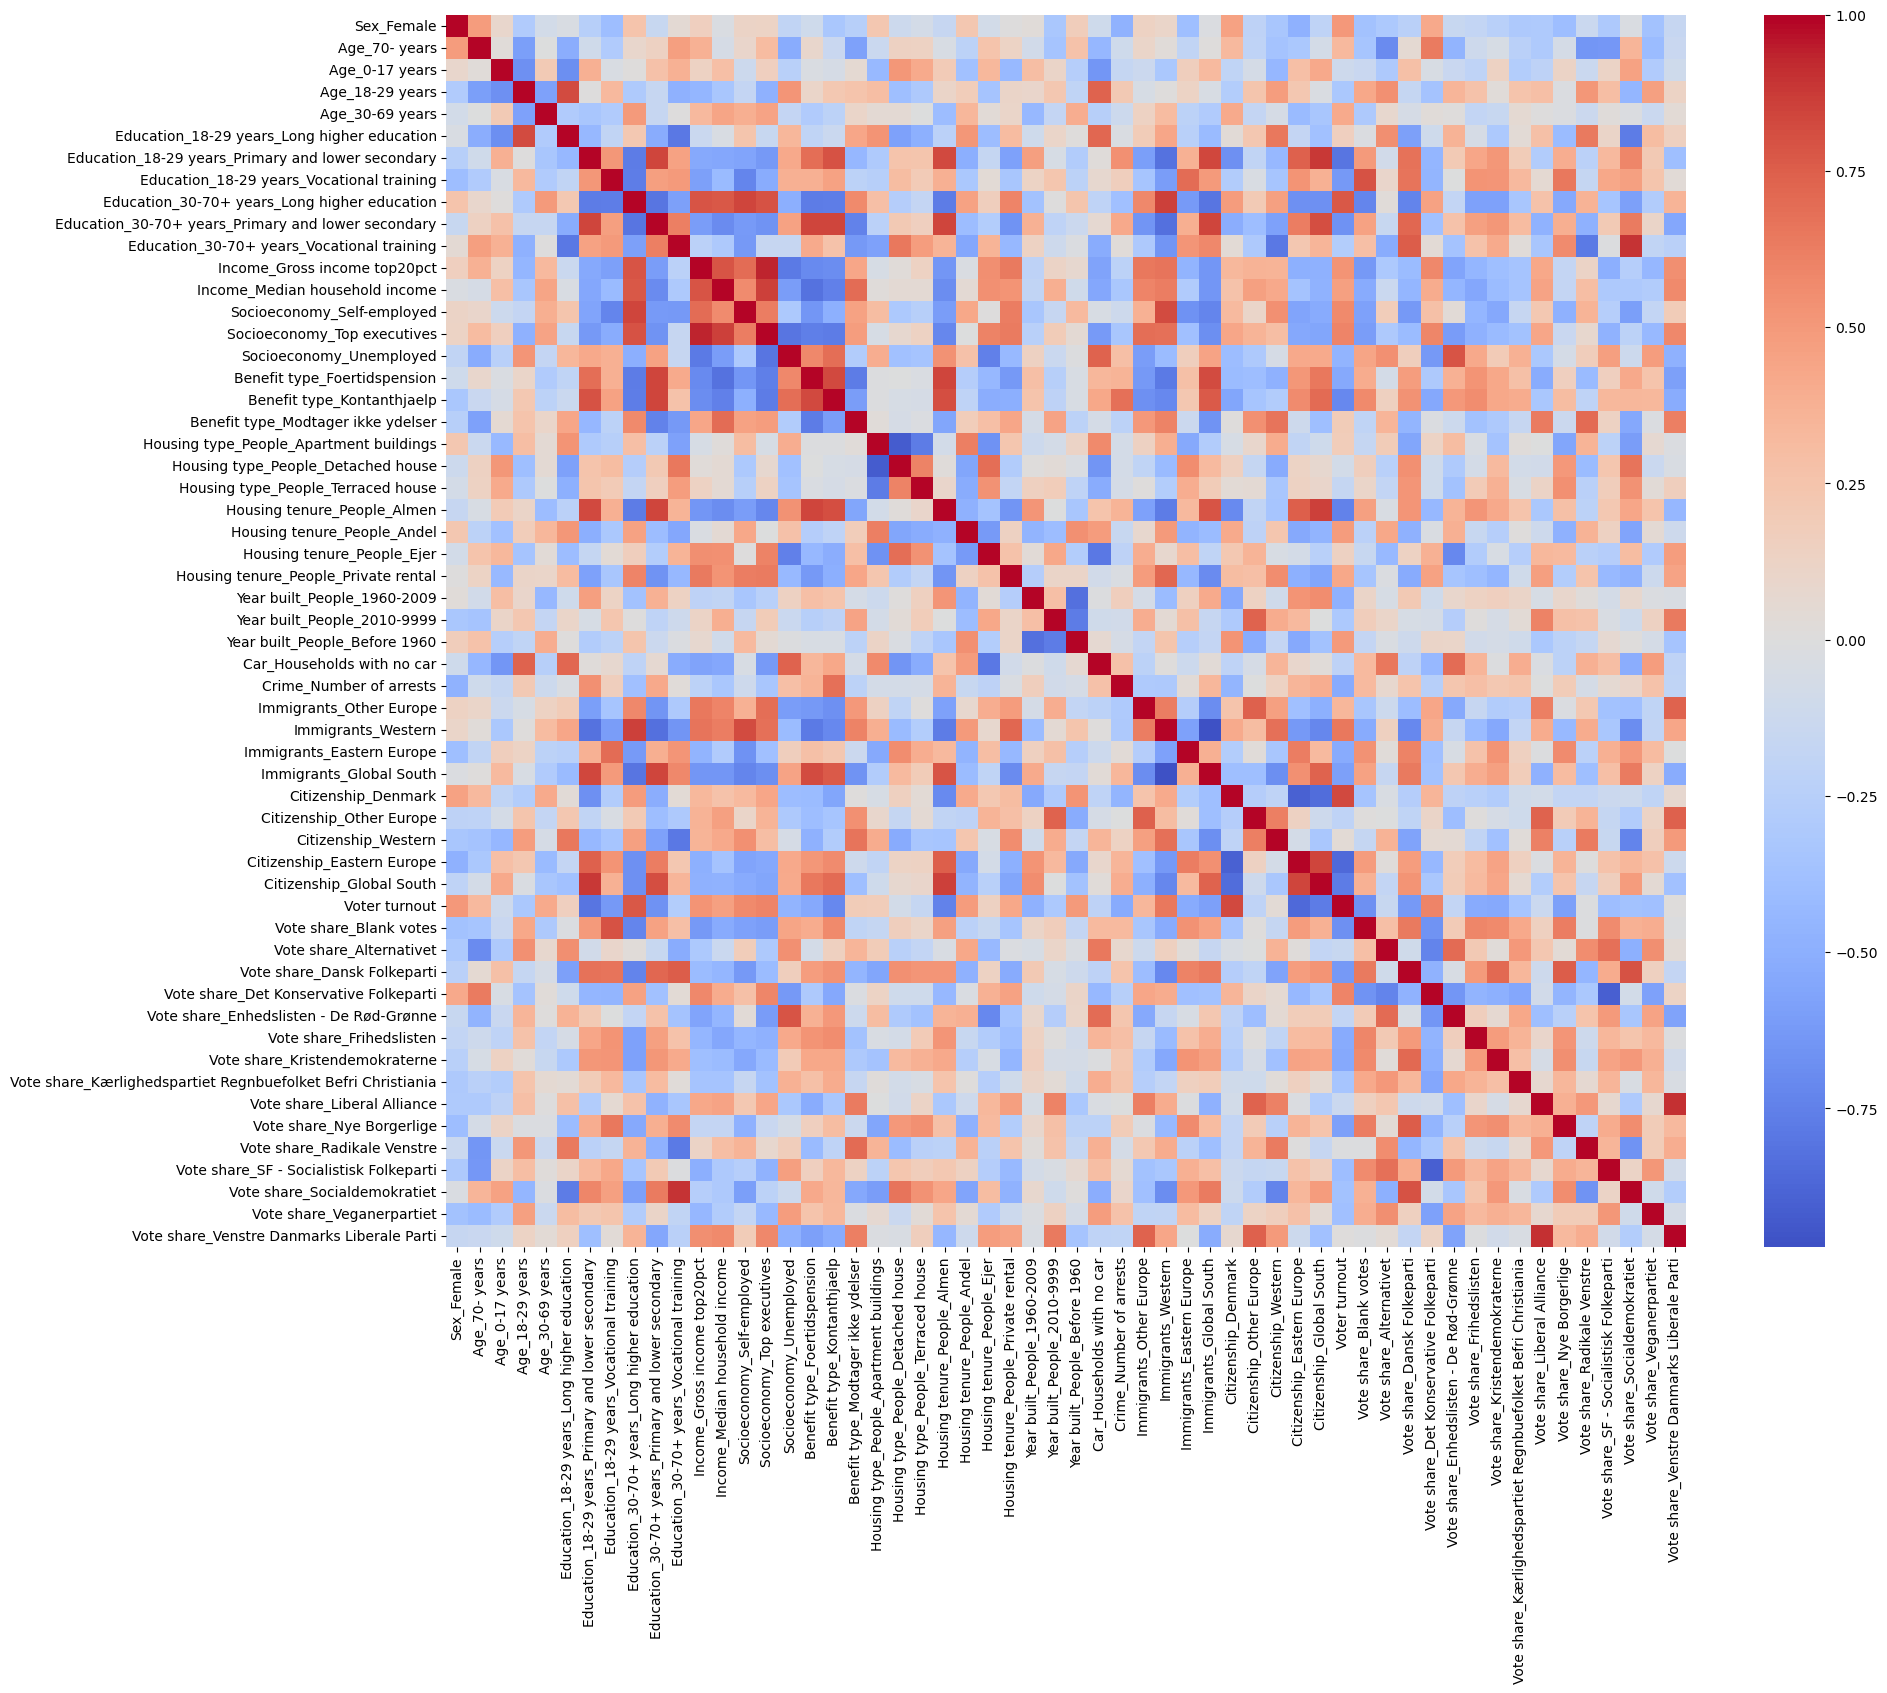

In [7]:
plt.figure(figsize=(20, 16))
sns.heatmap(df_num.corr(), cmap='coolwarm', center=0)

### Demographics vs votes

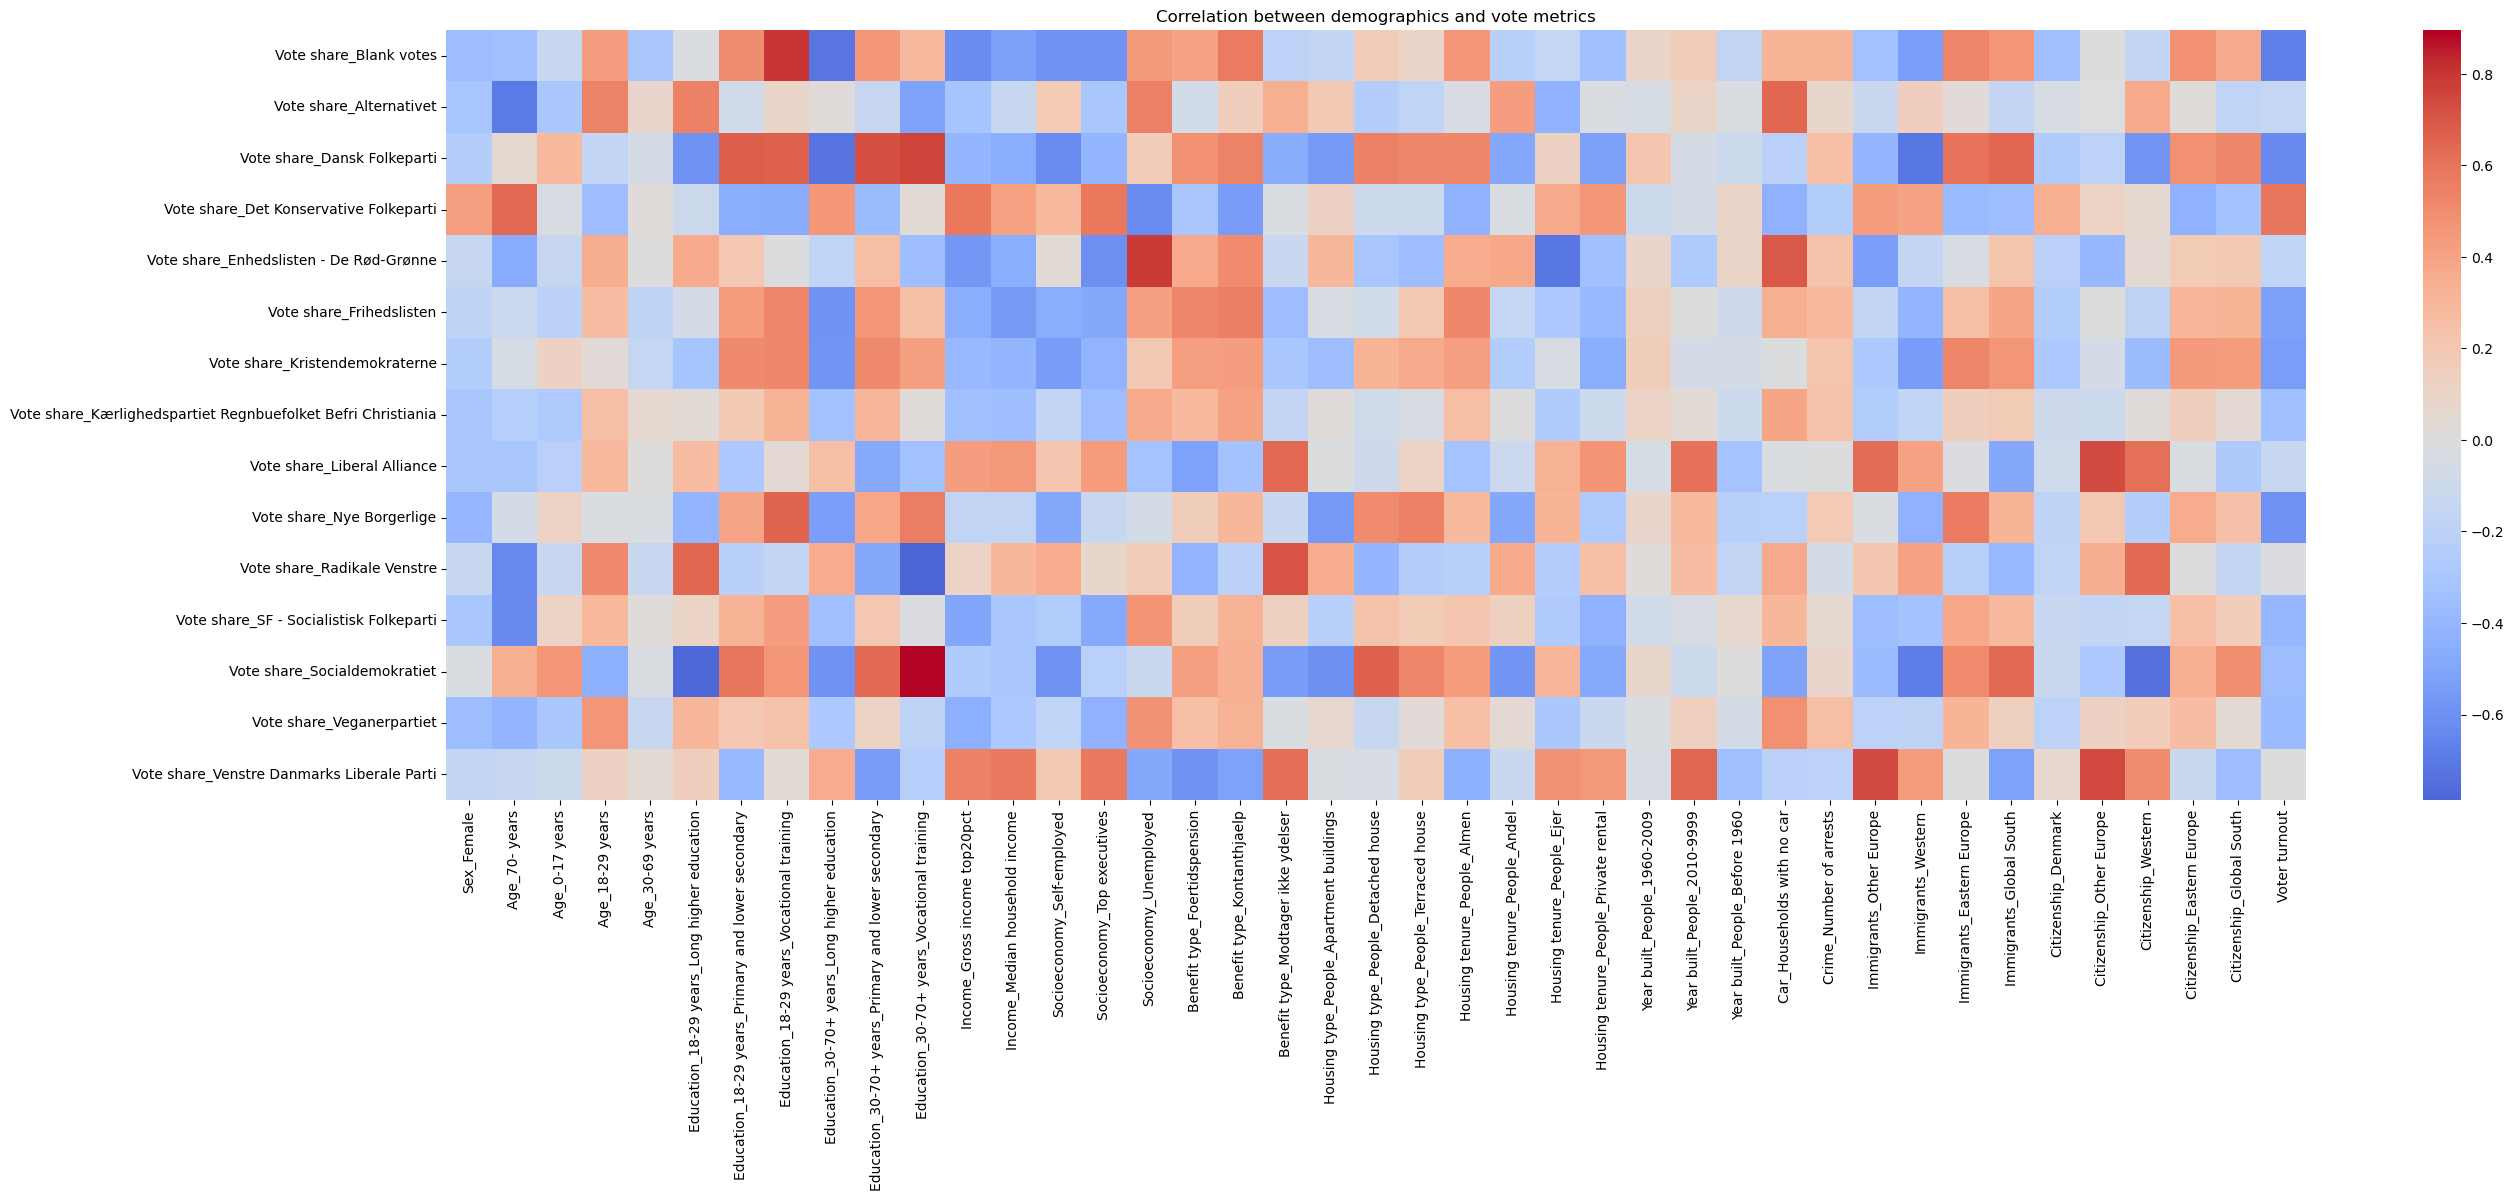

In [8]:
vote_cols = [c for c in df_num.columns if c.startswith('Vote share_')]
demo_cols = [c for c in df_num.columns if c not in vote_cols]
corr_matrix = df_num[vote_cols + demo_cols].corr().loc[vote_cols, demo_cols]
plt.figure(figsize=(30, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation between demographics and vote metrics")
plt.show()

In [9]:
# As list
corr_flat = corr_matrix.unstack()
top_positive = corr_flat[corr_flat > 0].sort_values(ascending=False).head(20)
top_negative = corr_flat[corr_flat < 0].sort_values().head(20)
print("Top 20 strongest positive correlations:")
print(top_positive)
print()
print("\nTop 20 strongest negative correlations:")
print(top_negative)

Top 20 strongest positive correlations:
Education_30-70+ years_Vocational training          Vote share_Socialdemokratiet                  0.895861
Education_18-29 years_Vocational training           Vote share_Blank votes                        0.799499
Socioeconomy_Unemployed                             Vote share_Enhedslisten - De Rød-Grønne       0.790074
Education_30-70+ years_Vocational training          Vote share_Dansk Folkeparti                   0.756028
Citizenship_Other Europe                            Vote share_Venstre Danmarks Liberale Parti    0.742949
                                                    Vote share_Liberal Alliance                   0.735719
Immigrants_Other Europe                             Vote share_Venstre Danmarks Liberale Parti    0.732129
Education_30-70+ years_Primary and lower secondary  Vote share_Dansk Folkeparti                   0.721796
Benefit type_Modtager ikke ydelser                  Vote share_Radikale Venstre                   0.7058

### Demographics vs demographics

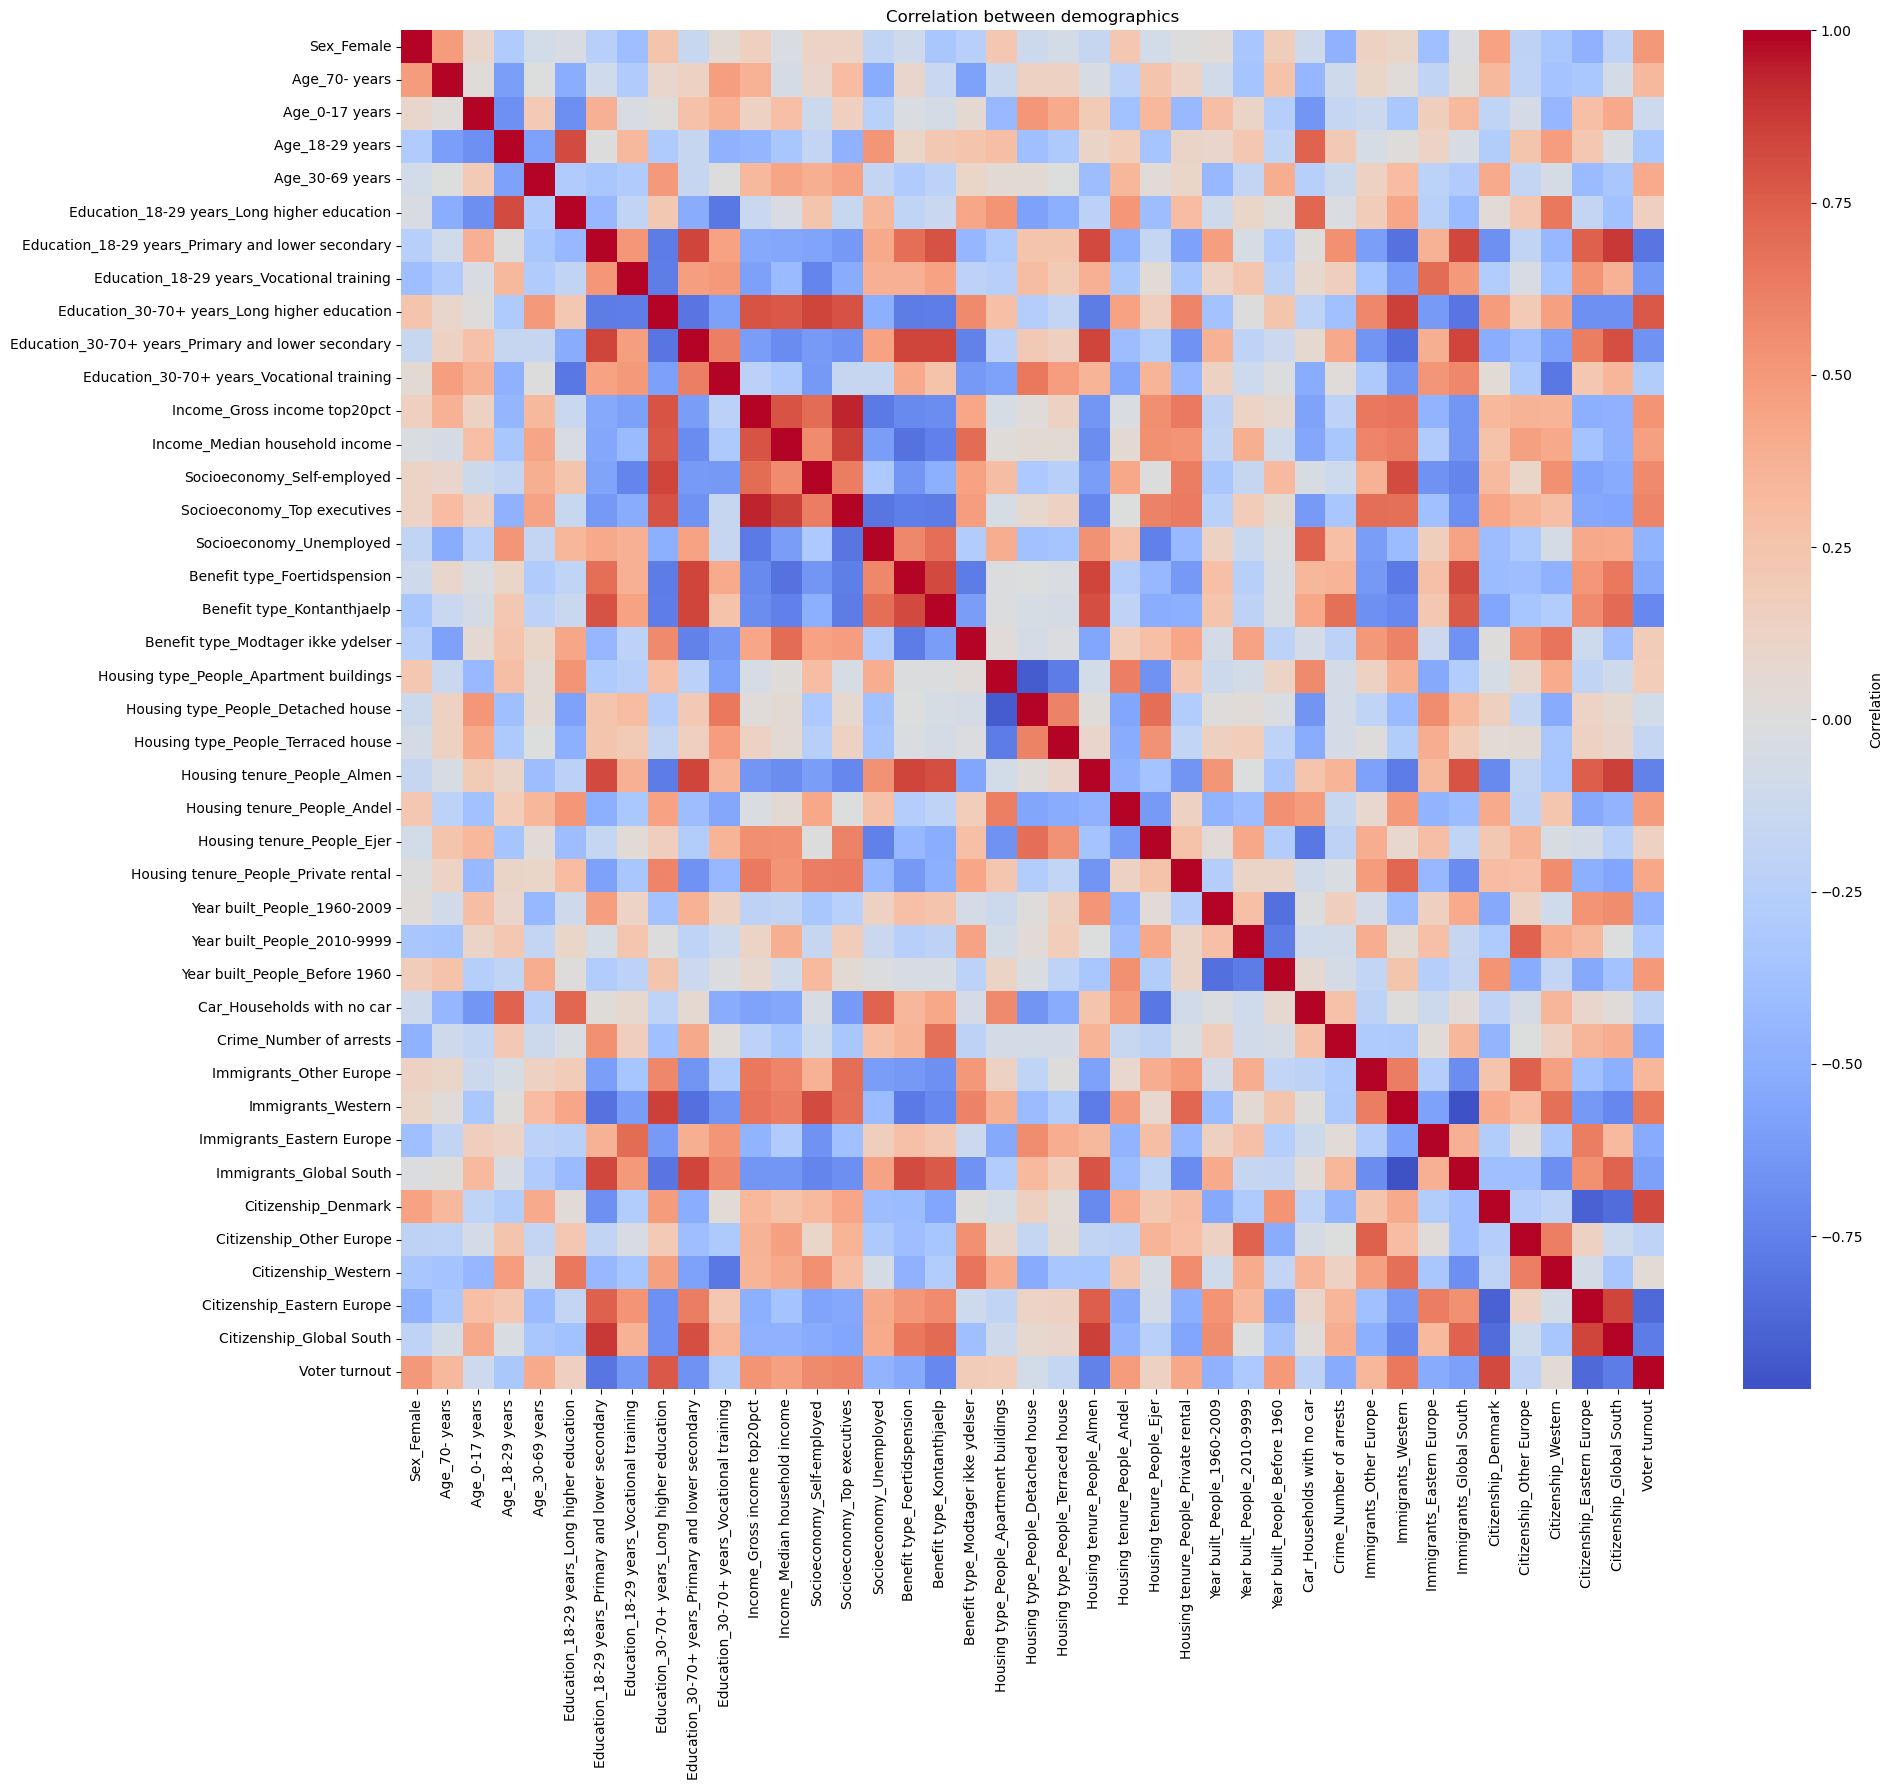

In [10]:
demo_cols = [c for c in df_num.columns if not c.startswith('Vote share_')]
corr_matrix = df_num[demo_cols].corr()
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, 
            cbar_kws={'label': 'Correlation'})
plt.title("Correlation between demographics")
plt.tight_layout()
plt.show()

In [11]:
# As list
demo_cols = [c for c in df_num.columns if not c.startswith('Vote share_')]
corr_matrix = df_num[demo_cols].corr()

corr_flat = corr_matrix.unstack()
# corr_flat = corr_flat[corr_flat < 0.99]

# Remove duplicate pairs (correlation of A-B is same as B-A)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        corr_pairs.append((var1, var2, corr_value))

corr_df = pd.DataFrame(corr_pairs, columns=['Variable_1', 'Variable_2', 'Correlation'])
corr_df_sorted = corr_df.sort_values('Correlation', ascending=False)

print("=" * 80)
print("TOP 20 STRONGEST POSITIVE CORRELATIONS (Demographics vs Demographics)")
print("=" * 80)
print(corr_df_sorted.head(20).to_string(index=False))

print("\n" + "=" * 80)
print("TOP 20 STRONGEST NEGATIVE CORRELATIONS (Demographics vs Demographics)")
print("=" * 80)
print(corr_df_sorted.tail(20).to_string(index=False))

TOP 20 STRONGEST POSITIVE CORRELATIONS (Demographics vs Demographics)
                                        Variable_1                                         Variable_2  Correlation
                      Income_Gross income top20pct                        Socioeconomy_Top executives     0.937816
 Education_18-29 years_Primary and lower secondary                           Citizenship_Global South     0.877837
      Education_30-70+ years_Long higher education                                 Immigrants_Western     0.858212
                    Income_Median household income                        Socioeconomy_Top executives     0.856945
                       Housing tenure_People_Almen                           Citizenship_Global South     0.854907
 Education_18-29 years_Primary and lower secondary Education_30-70+ years_Primary and lower secondary     0.844595
                      Benefit type_Foertidspension                        Housing tenure_People_Almen     0.843124
Education_

The correlations seem to show that areas with higher incomes and larger shares of top executives are strongly associated with long higher education and with Western immigrants, and these areas also tend to have higher voter turnout. This points to a concentration of educational, economic, and civic resources in certain polling areas.

On the other hand, polling areas with higher shares of residents with only primary or lower secondary education are strongly correlated with Global South and Eastern European citizenship and immigration, a higher share of social housing (almen bolig), and welfare benefits such as disability pension and 'kontanthjælp'. These patterns suggest that lower education, welfare dependency, and certain housing types often co-occur spatially.
Some correlations mainly reflect structural or definitional relationships, such as the near-perfect link between residents aged 70+ and old-age pension, or the strong negative correlations between different housing types

### Votes vs votes

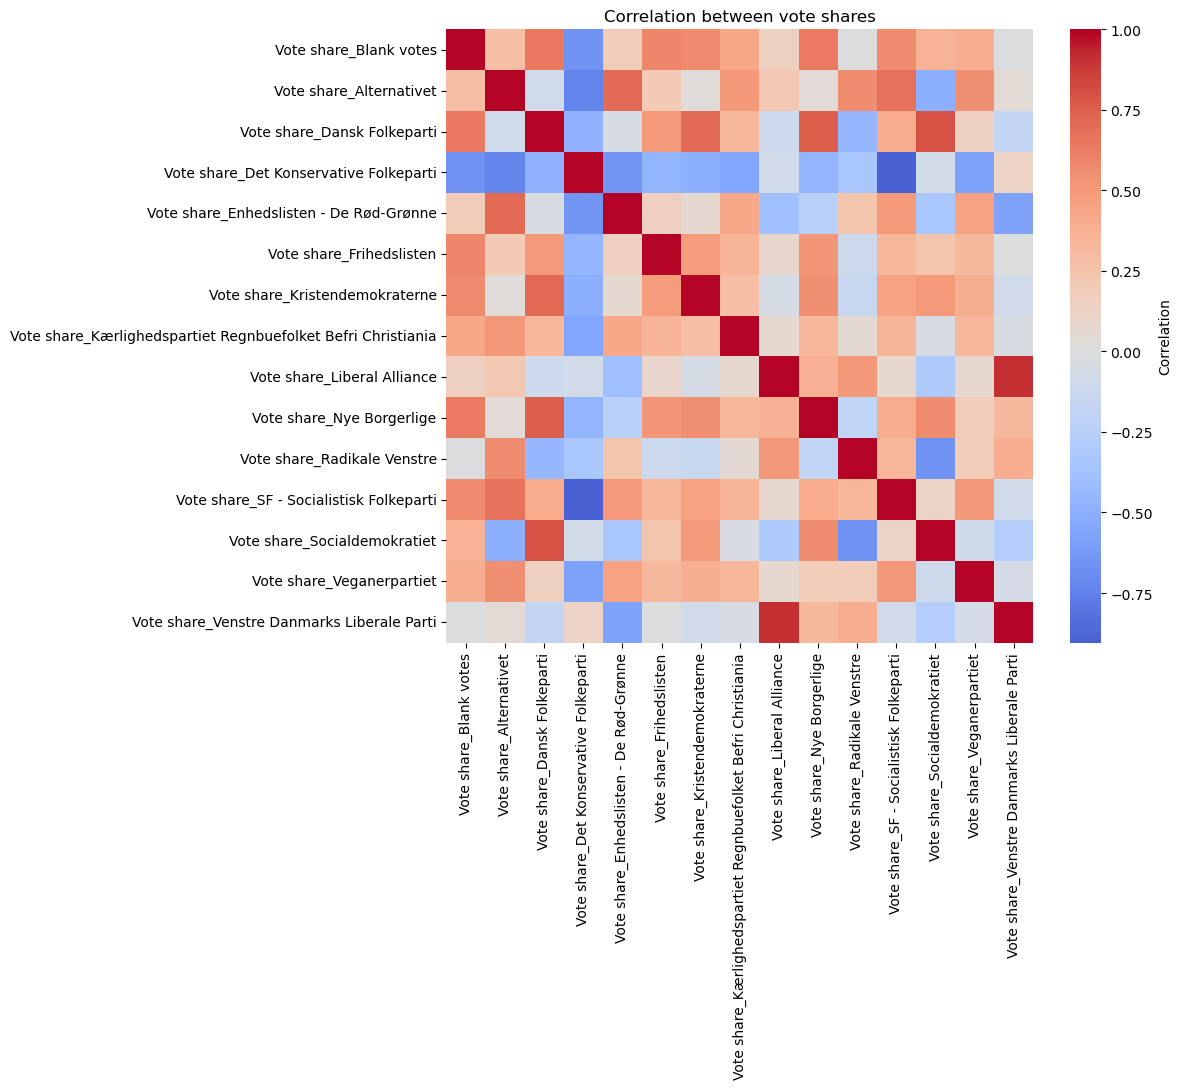

In [12]:
vote_cols = [c for c in df_num.columns if c.startswith('Vote share_')]
corr_matrix = df_num[vote_cols].corr()
plt.figure(figsize=(12, 11))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, 
            cbar_kws={'label': 'Correlation'})
plt.title("Correlation between vote shares")
plt.tight_layout()
plt.show()

## Distributions

In [13]:
main_demographics = [
    'Age_0-17 years',
    'Age_18-29 years',
    'Age_30-69 years', 
    'Age_70- years',
    'Education_30-70+ years_Long higher education',
    'Education_30-70+ years_Primary and lower secondary',
    'Education_30-70+ years_Vocational training',
    'Income_Median household income',
    'Income_Gross income top20pct',
    'Benefit type_Modtager ikke ydelser',
    'Benefit type_Kontanthjaelp',
    'Benefit type_Foertidspension',
    'Housing type_People_Apartment buildings',
    'Housing type_People_Detached house',
    'Housing tenure_People_Ejer',
    'Housing tenure_People_Almen',
    'Citizenship_Denmark',
    'Immigrants_Global South',
    'Immigrants_Eastern Europe',
    'Immigrants_Western',
    'Car_Households with no car',
    'Crime_Number of arrests',
    'Socioeconomy_Self-employed',
    'Year built_People_2010-9999'
]

main_parties = [
    'Vote share_Enhedslisten - De Rød-Grønne',
    'Vote share_Socialdemokratiet',
    'Vote share_Det Konservative Folkeparti',
    'Vote share_Radikale Venstre',
    'Vote share_SF - Socialistisk Folkeparti',
    'Vote share_Venstre Danmarks Liberale Parti',
    'Vote share_Alternativet',
    'Vote share_Liberal Alliance',
    'Vote share_Nye Borgerlige',
    'Vote share_Dansk Folkeparti'
]

### Histograms

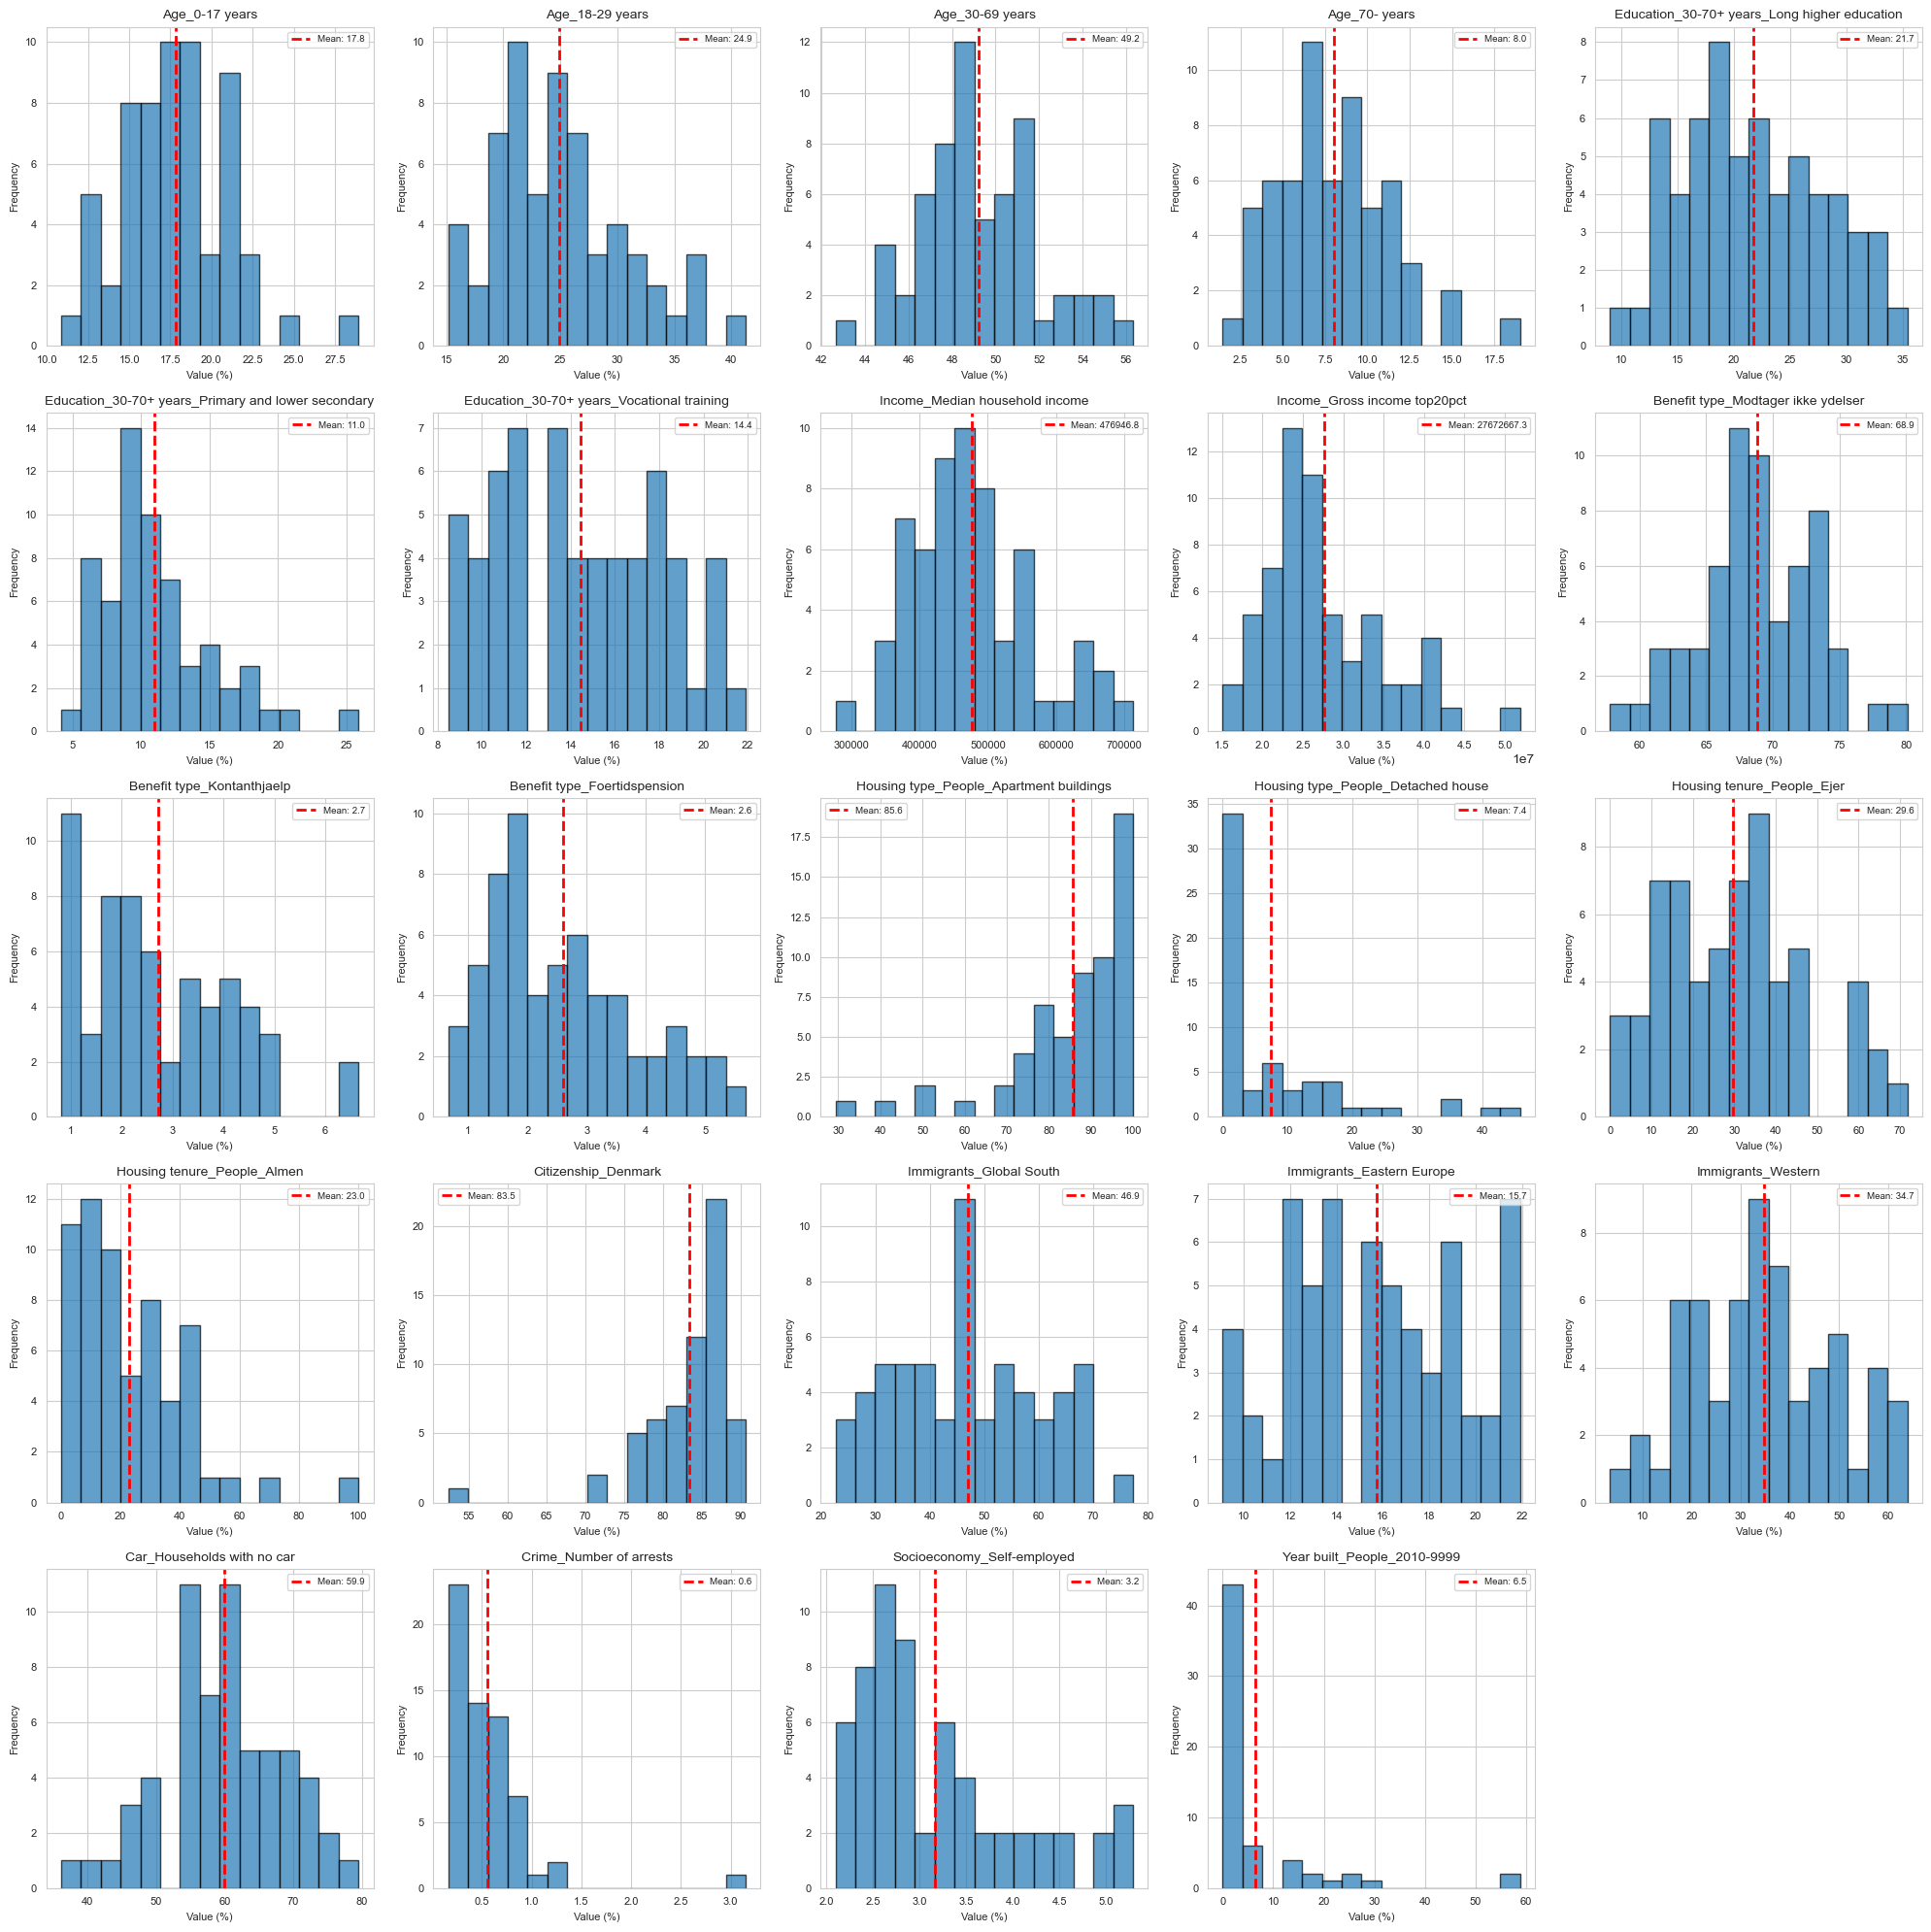

In [14]:
# Set style
sns.set_style("whitegrid")

# Create subplots
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for idx, col in enumerate(main_demographics):
    axes[idx].hist(df_num[col], bins=15, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=10)
    axes[idx].set_xlabel('Value (%)', fontsize=8)
    axes[idx].set_ylabel('Frequency', fontsize=8)
    axes[idx].tick_params(labelsize=8)
    
    # Add mean line
    mean_val = df_num[col].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {mean_val:.1f}')
    axes[idx].legend(fontsize=7)

# Remove empty subplots
for idx in range(len(main_demographics), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

### Violin plots

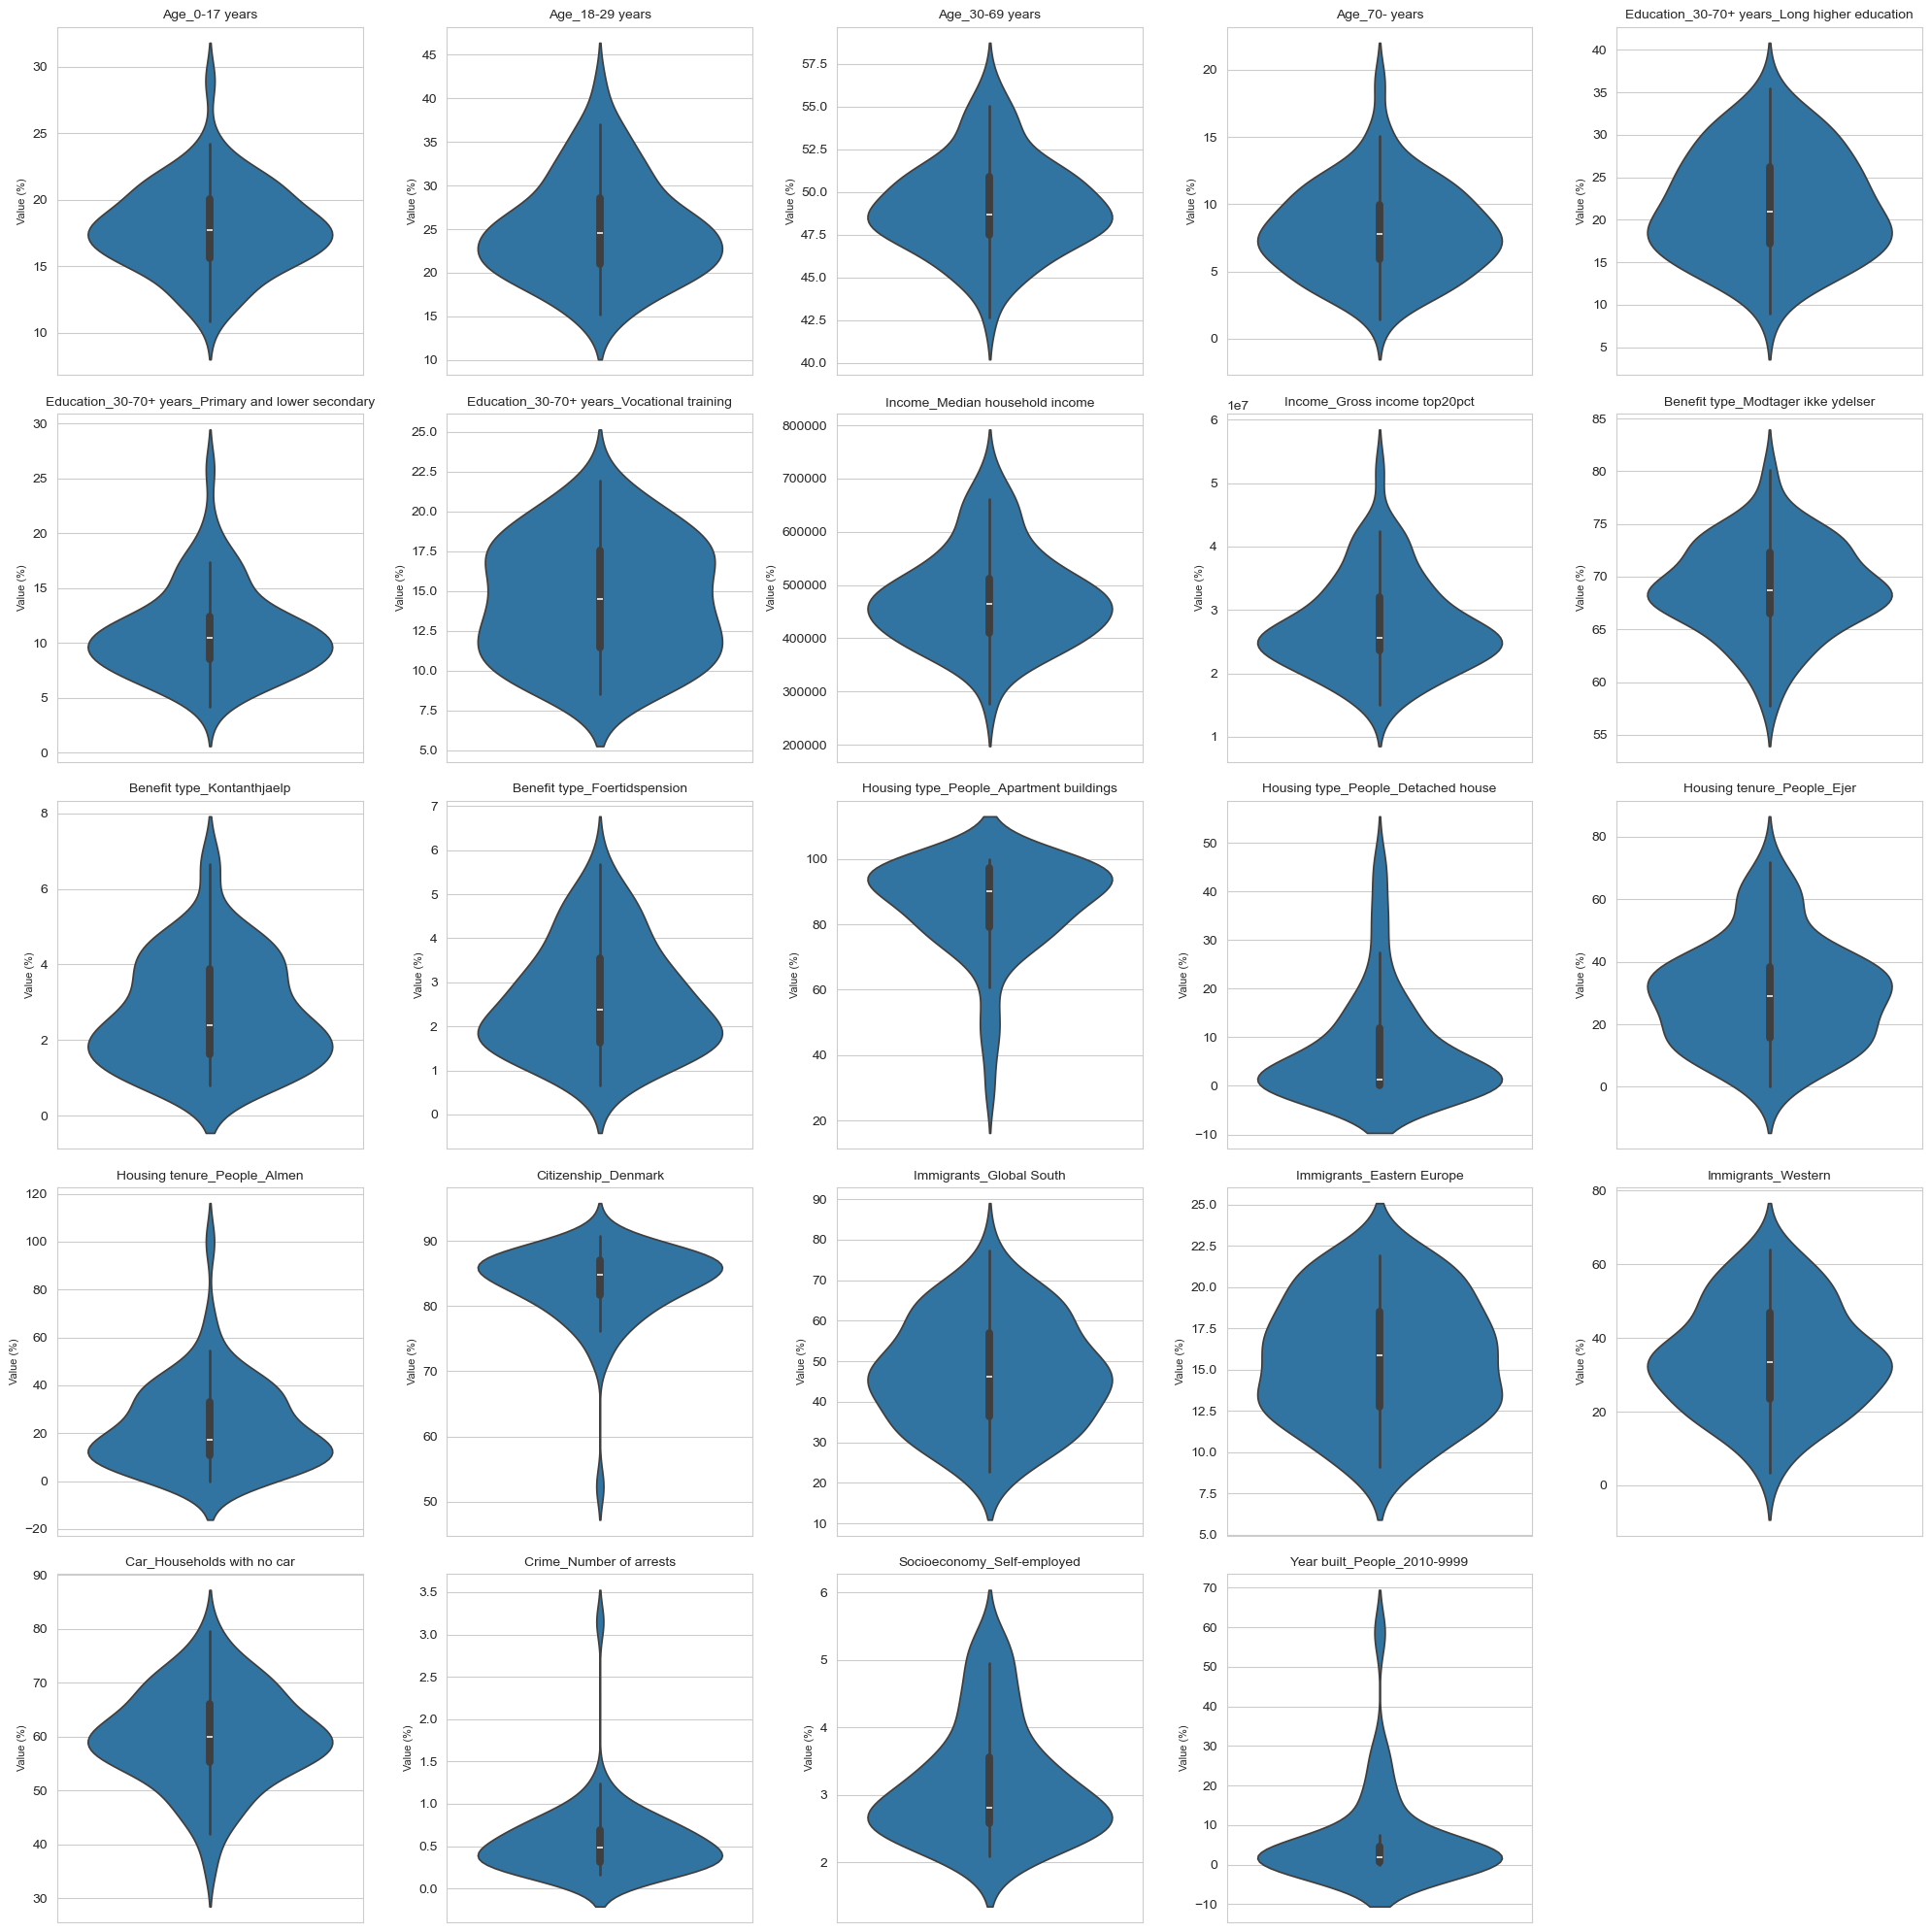

In [15]:
df_main = df_num[main_demographics].copy()

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for idx, col in enumerate(main_demographics):
    sns.violinplot(y=df_main[col], ax=axes[idx], inner='box')
    axes[idx].set_title(col, fontsize=10)
    axes[idx].set_ylabel('Value (%)', fontsize=8)

for idx in range(len(main_demographics), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

The violin plot shows that we have outliers for some demographic features. As discussed earlier, we do not wish to remove or transofrm these.

## Scatter plots

In [16]:
vote_cols = [c for c in df_num.columns if c.startswith('Vote share_')]
party_means = df_num[vote_cols].mean().sort_values(ascending=False)
print("Top 10 parties by average vote share:")
print(party_means.head(10))

Top 10 parties by average vote share:
Vote share_Enhedslisten - De Rød-Grønne       23.854923
Vote share_Socialdemokratiet                  17.865766
Vote share_Det Konservative Folkeparti        16.249561
Vote share_Radikale Venstre                   11.382506
Vote share_SF - Socialistisk Folkeparti       10.277461
Vote share_Venstre Danmarks Liberale Parti     7.157356
Vote share_Alternativet                        2.577492
Vote share_Liberal Alliance                    2.418737
Vote share_Nye Borgerlige                      1.965498
Vote share_Dansk Folkeparti                    1.876463
dtype: float64


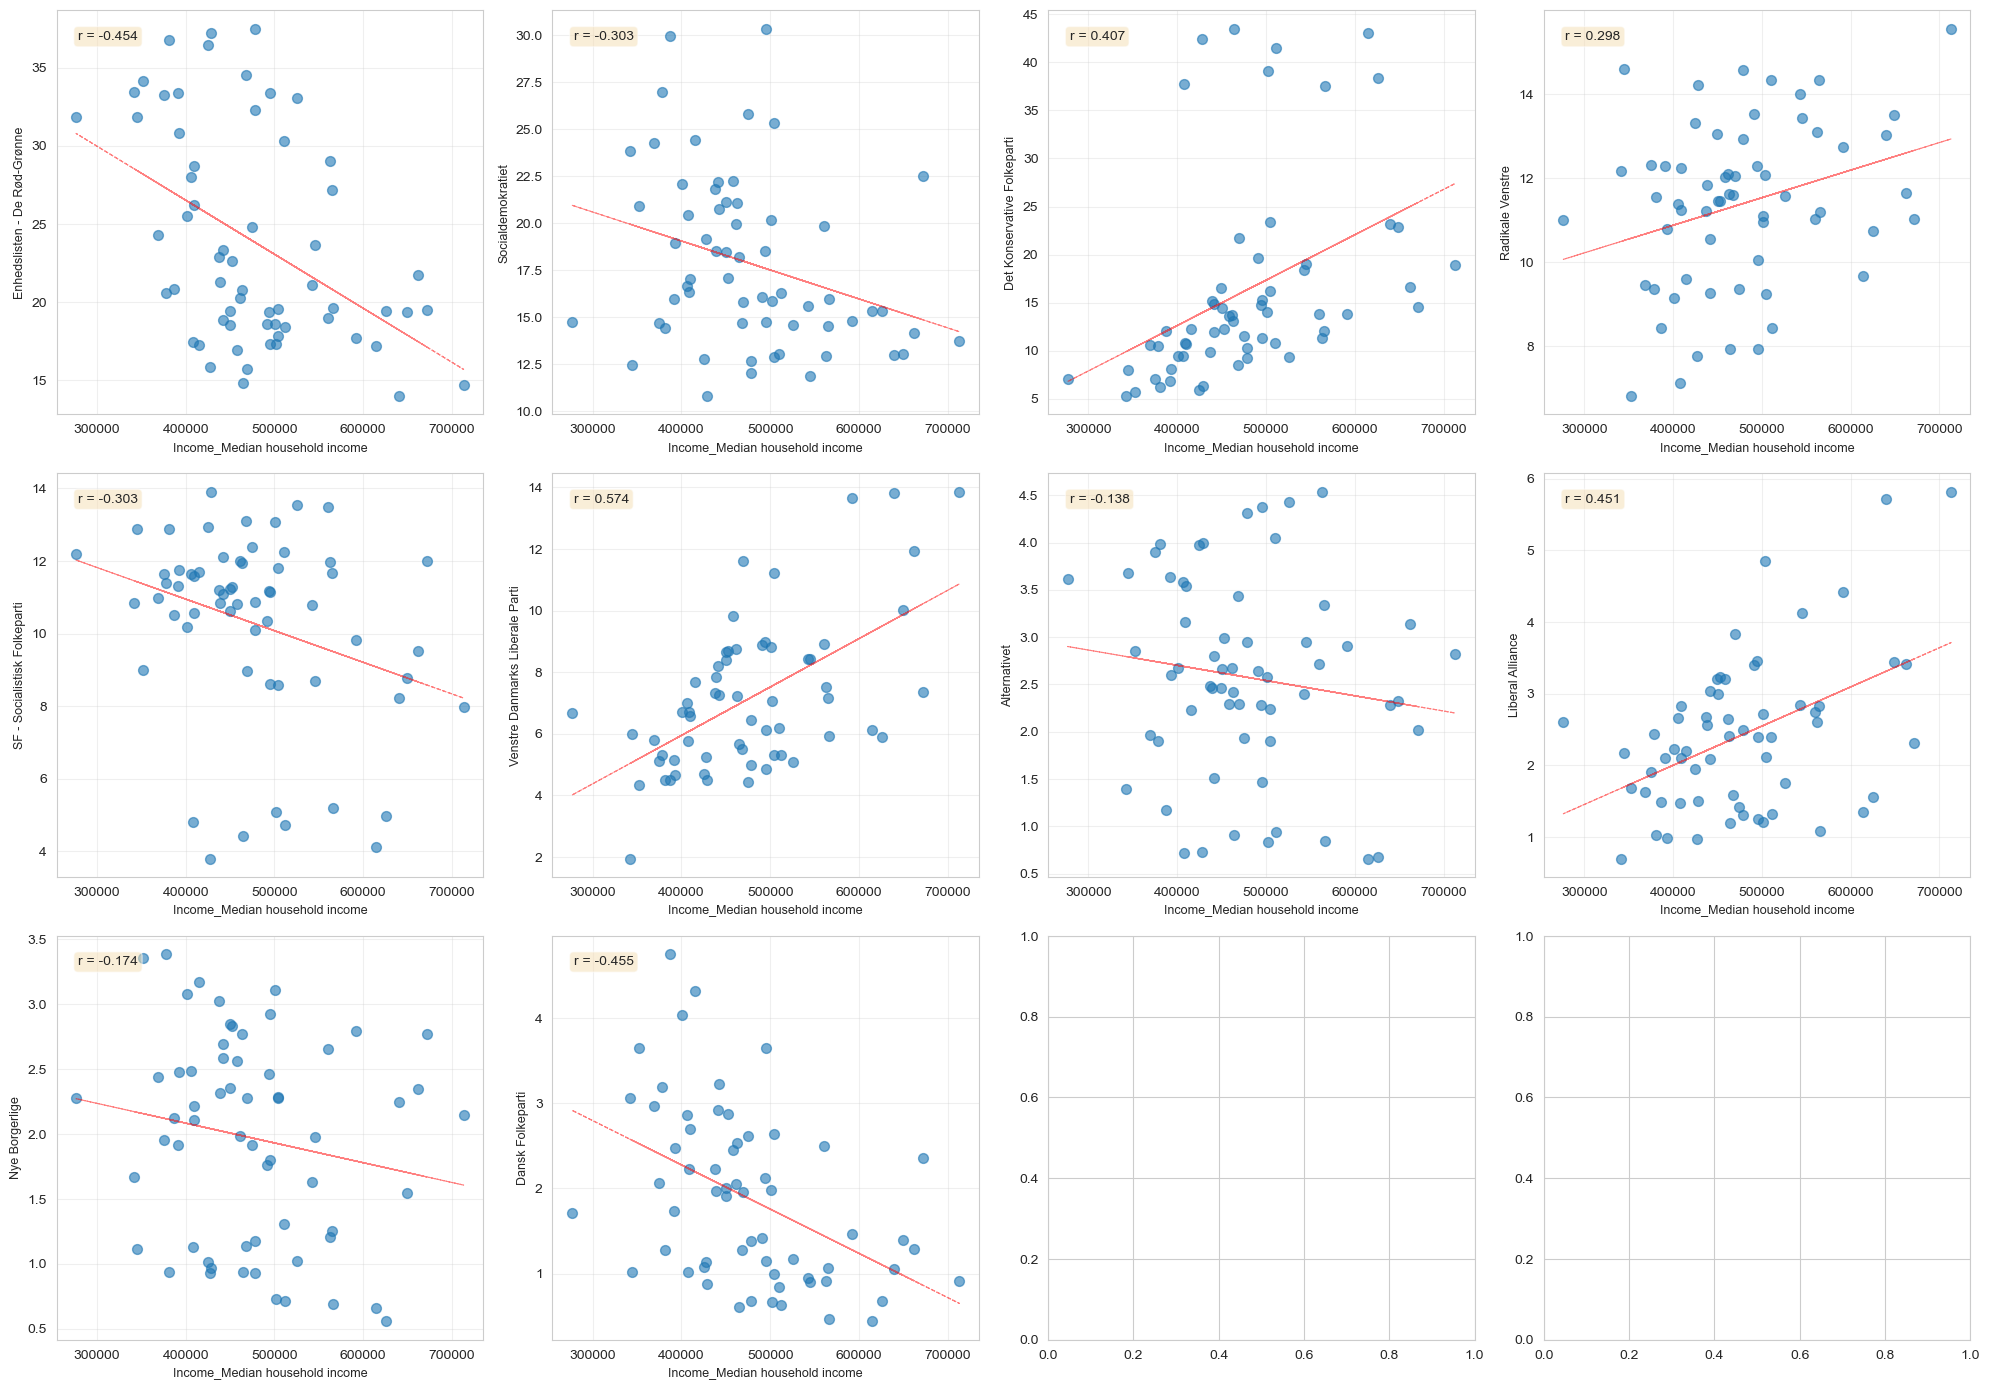

In [17]:
# Income vs main parties
demographic = 'Income_Median household income'

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for idx, party in enumerate(main_parties):
    axes[idx].scatter(df_num[demographic], df_num[party], alpha=0.6, s=50)
    axes[idx].set_xlabel(demographic, fontsize=9)
    axes[idx].set_ylabel(party.replace('Vote share_', ''), fontsize=9)
    axes[idx].grid(alpha=0.3)
    
    z = np.polyfit(df_num[demographic], df_num[party], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_num[demographic], p(df_num[demographic]), 
                   "r--", alpha=0.5, linewidth=0.8)
    
    corr = df_num[[demographic, party]].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

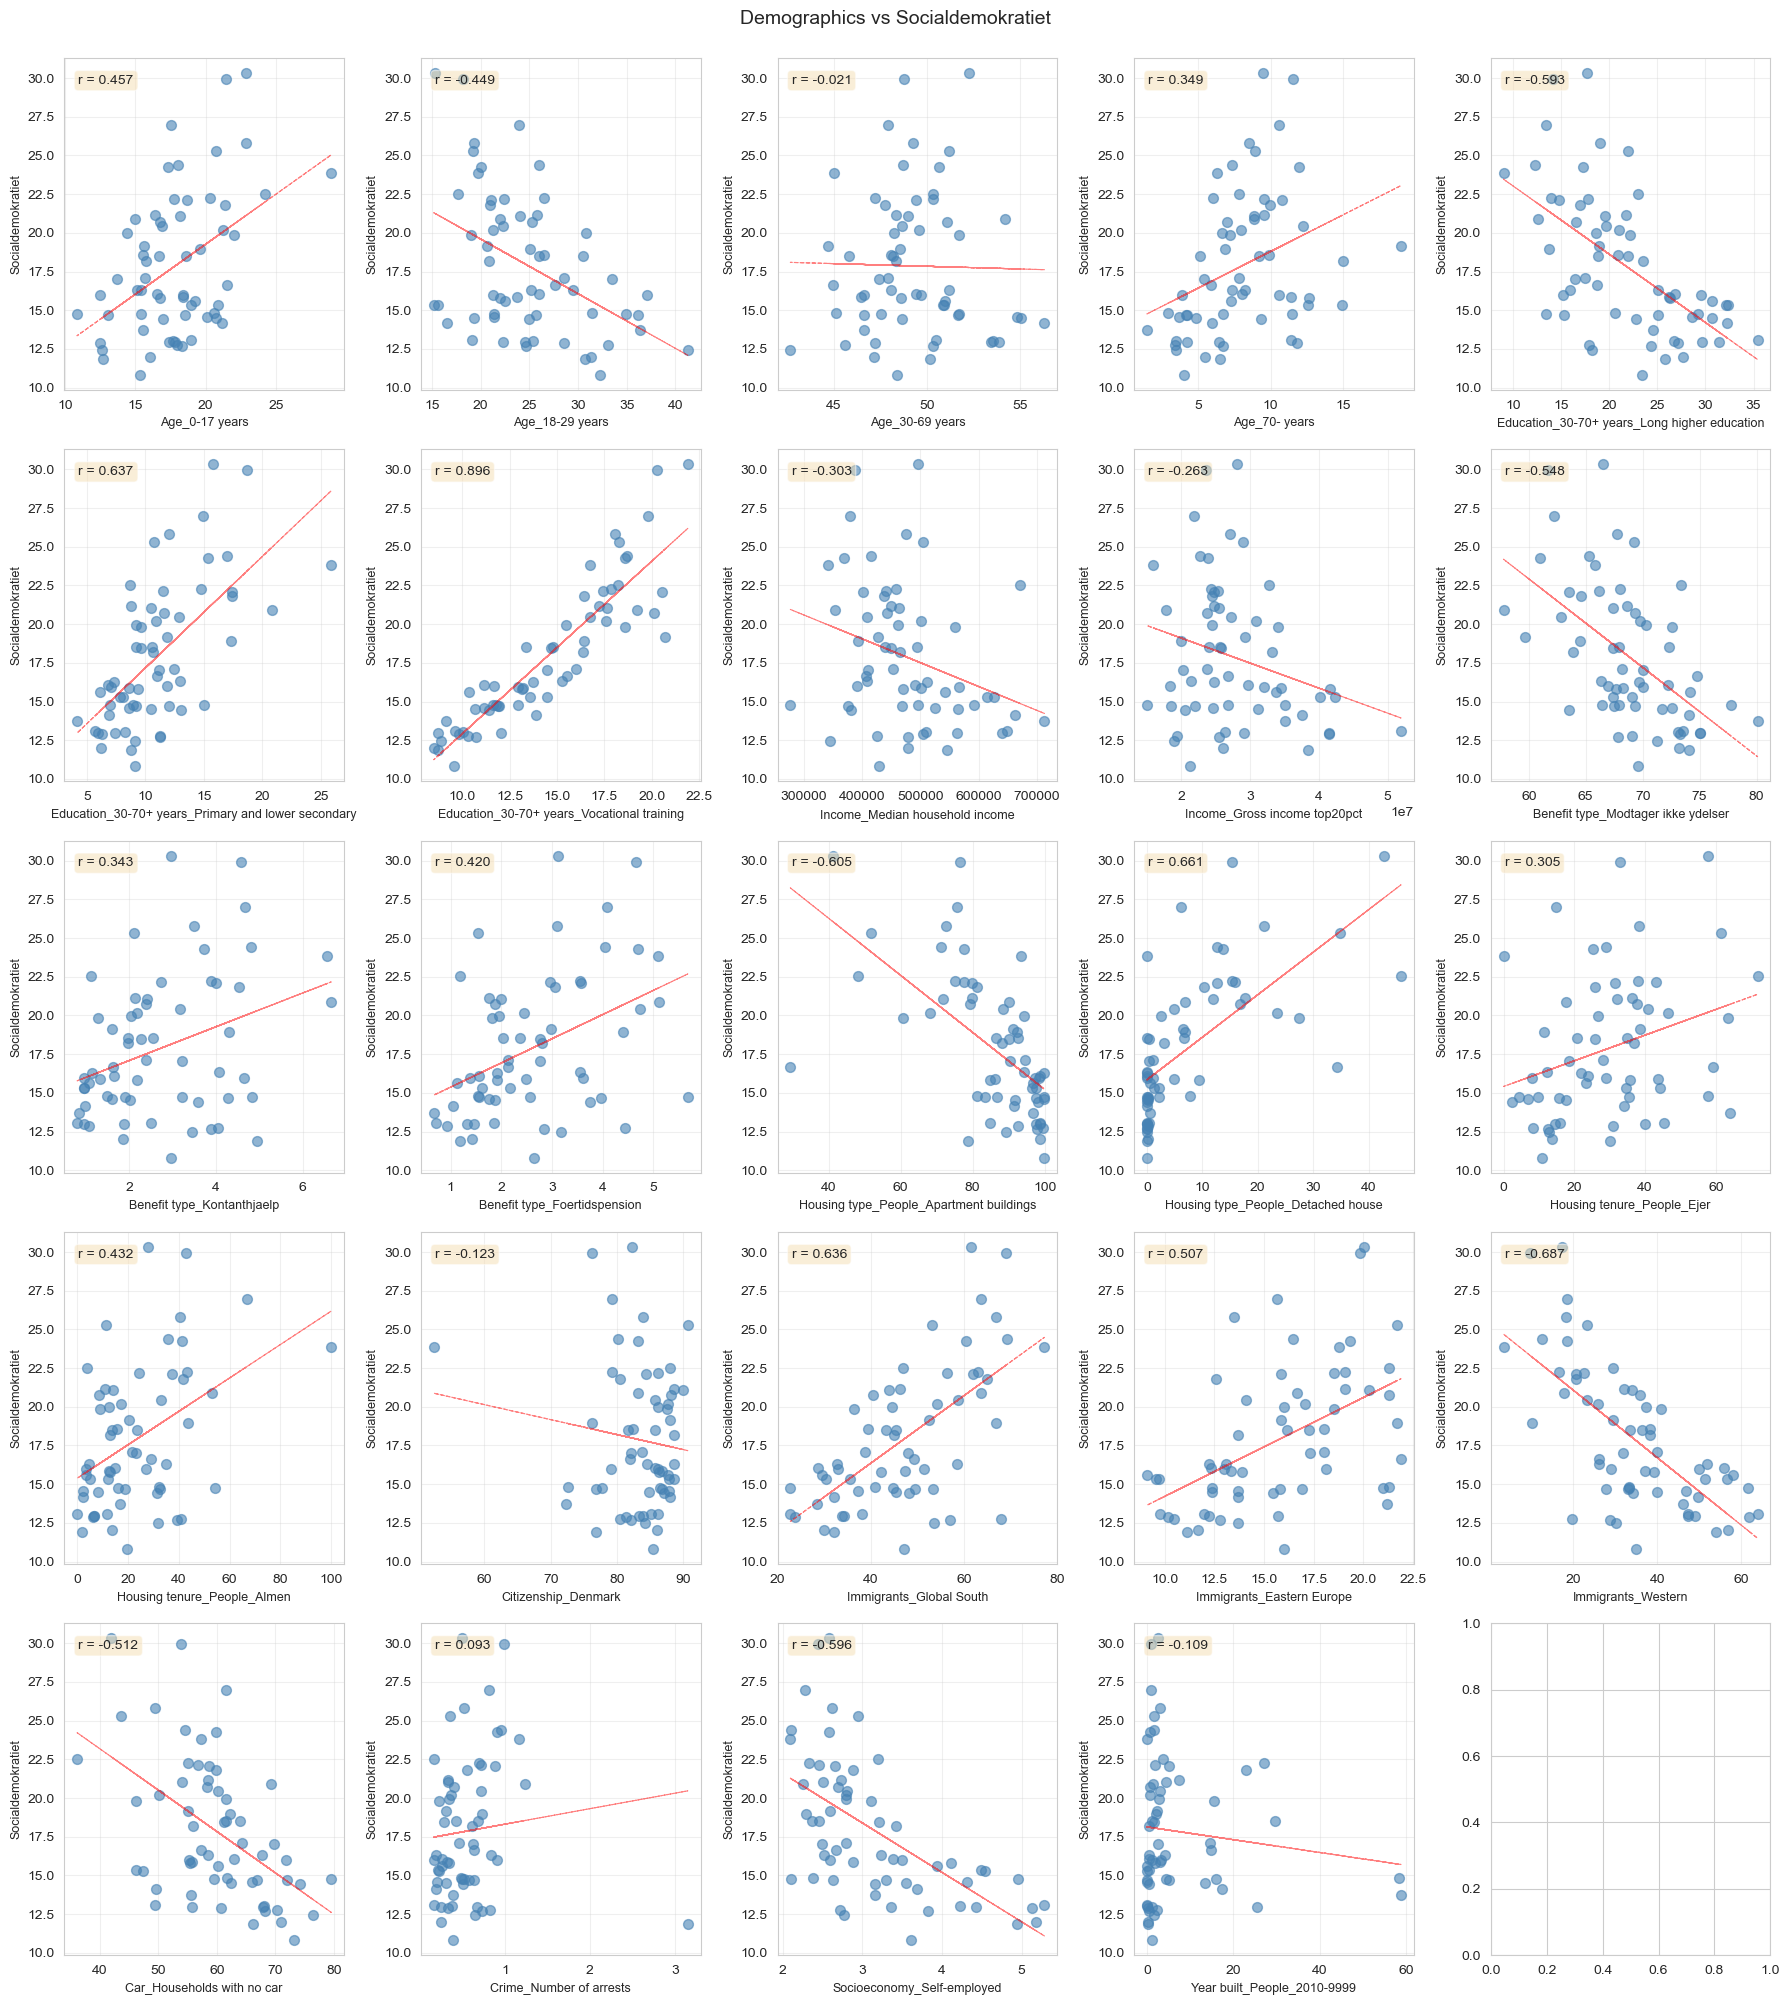

In [18]:
# Main demographics vs Socialdemokratiet
party = 'Vote share_Socialdemokratiet'

fig, axes = plt.subplots(5, 5, figsize=(18, 20))
axes = axes.flatten()

for idx, demo in enumerate(main_demographics):
    axes[idx].scatter(df_num[demo], df_num[party], alpha=0.6, s=50, color='steelblue')
    axes[idx].set_xlabel(demo, fontsize=9)
    axes[idx].set_ylabel(party.replace('Vote share_', ''), fontsize=9)
    axes[idx].grid(alpha=0.3)
    
    # Trend line
    z = np.polyfit(df_num[demo], df_num[party], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_num[demo], p(df_num[demo]), "r--", alpha=0.5, linewidth=0.8)
    
    # Correlation
    corr = df_num[[demo, party]].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Demographics vs {party.replace("Vote share_", "")}', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

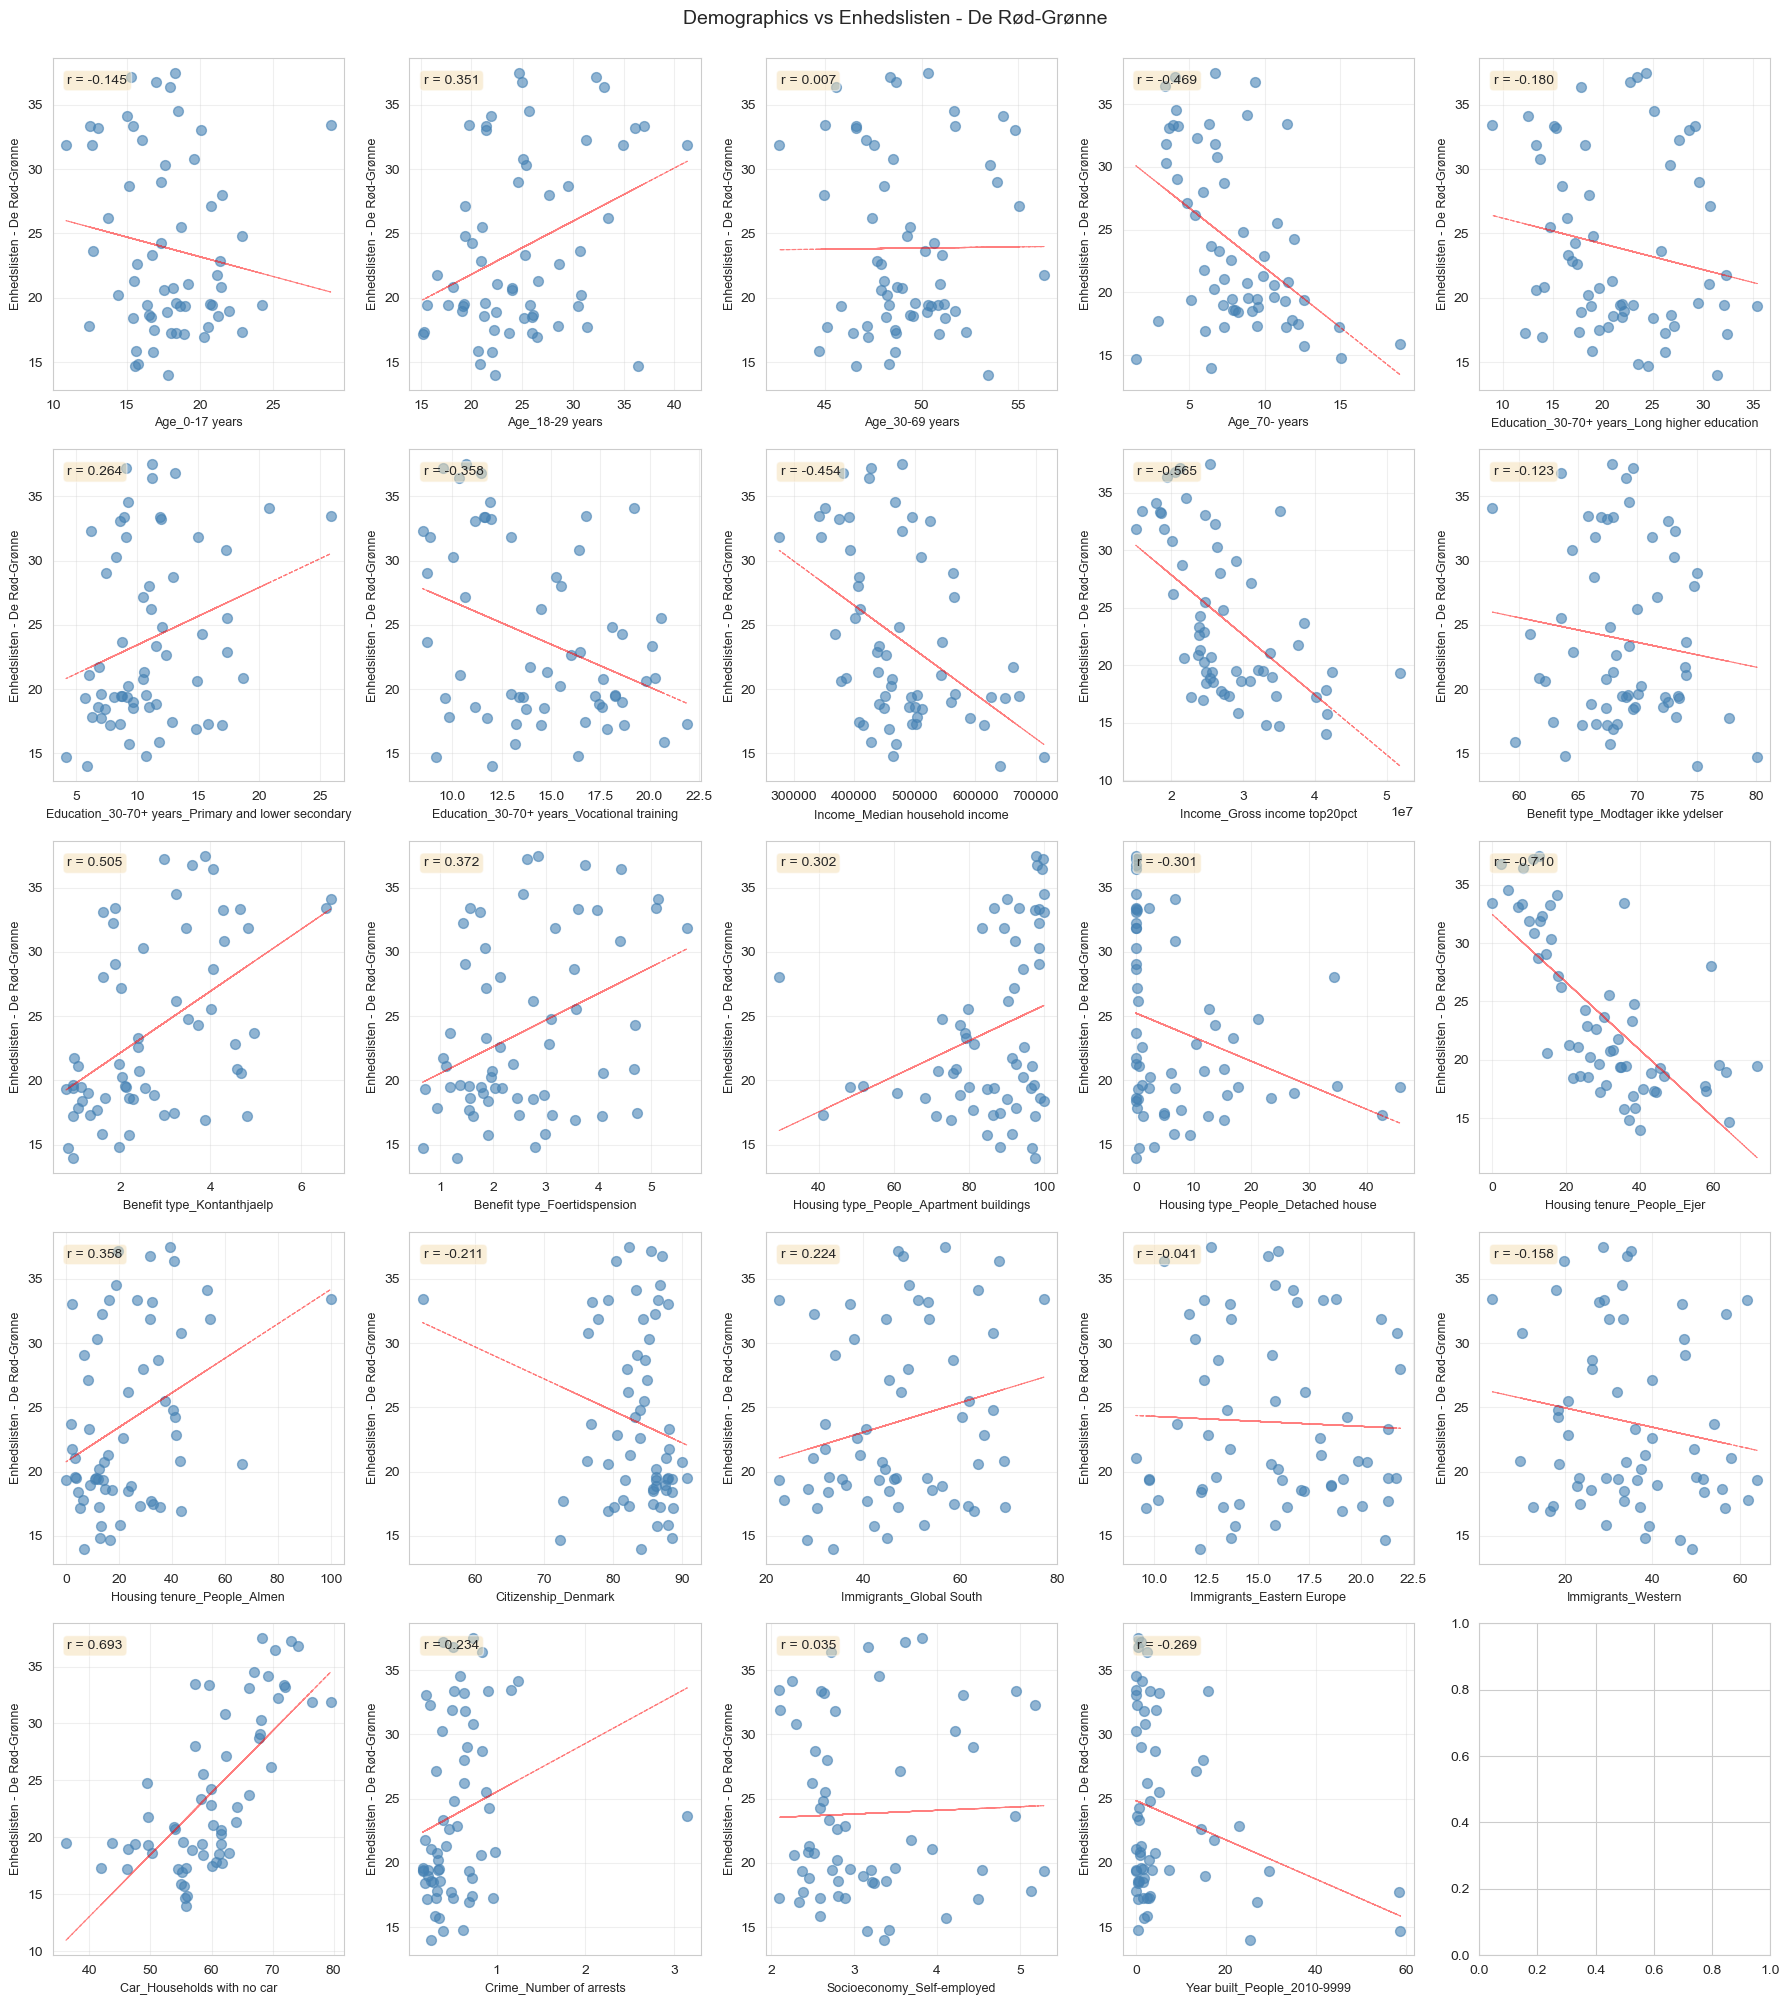

In [19]:
# Main demographics vs Enhedslisten
party = 'Vote share_Enhedslisten - De Rød-Grønne'

fig, axes = plt.subplots(5, 5, figsize=(18, 20))
axes = axes.flatten()

for idx, demo in enumerate(main_demographics):
    axes[idx].scatter(df_num[demo], df_num[party], alpha=0.6, s=50, color='steelblue')
    axes[idx].set_xlabel(demo, fontsize=9)
    axes[idx].set_ylabel(party.replace('Vote share_', ''), fontsize=9)
    axes[idx].grid(alpha=0.3)
    
    # Trend line
    z = np.polyfit(df_num[demo], df_num[party], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_num[demo], p(df_num[demo]), "r--", alpha=0.5, linewidth=0.8)
    
    # Correlation
    corr = df_num[[demo, party]].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Demographics vs {party.replace("Vote share_", "")}', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

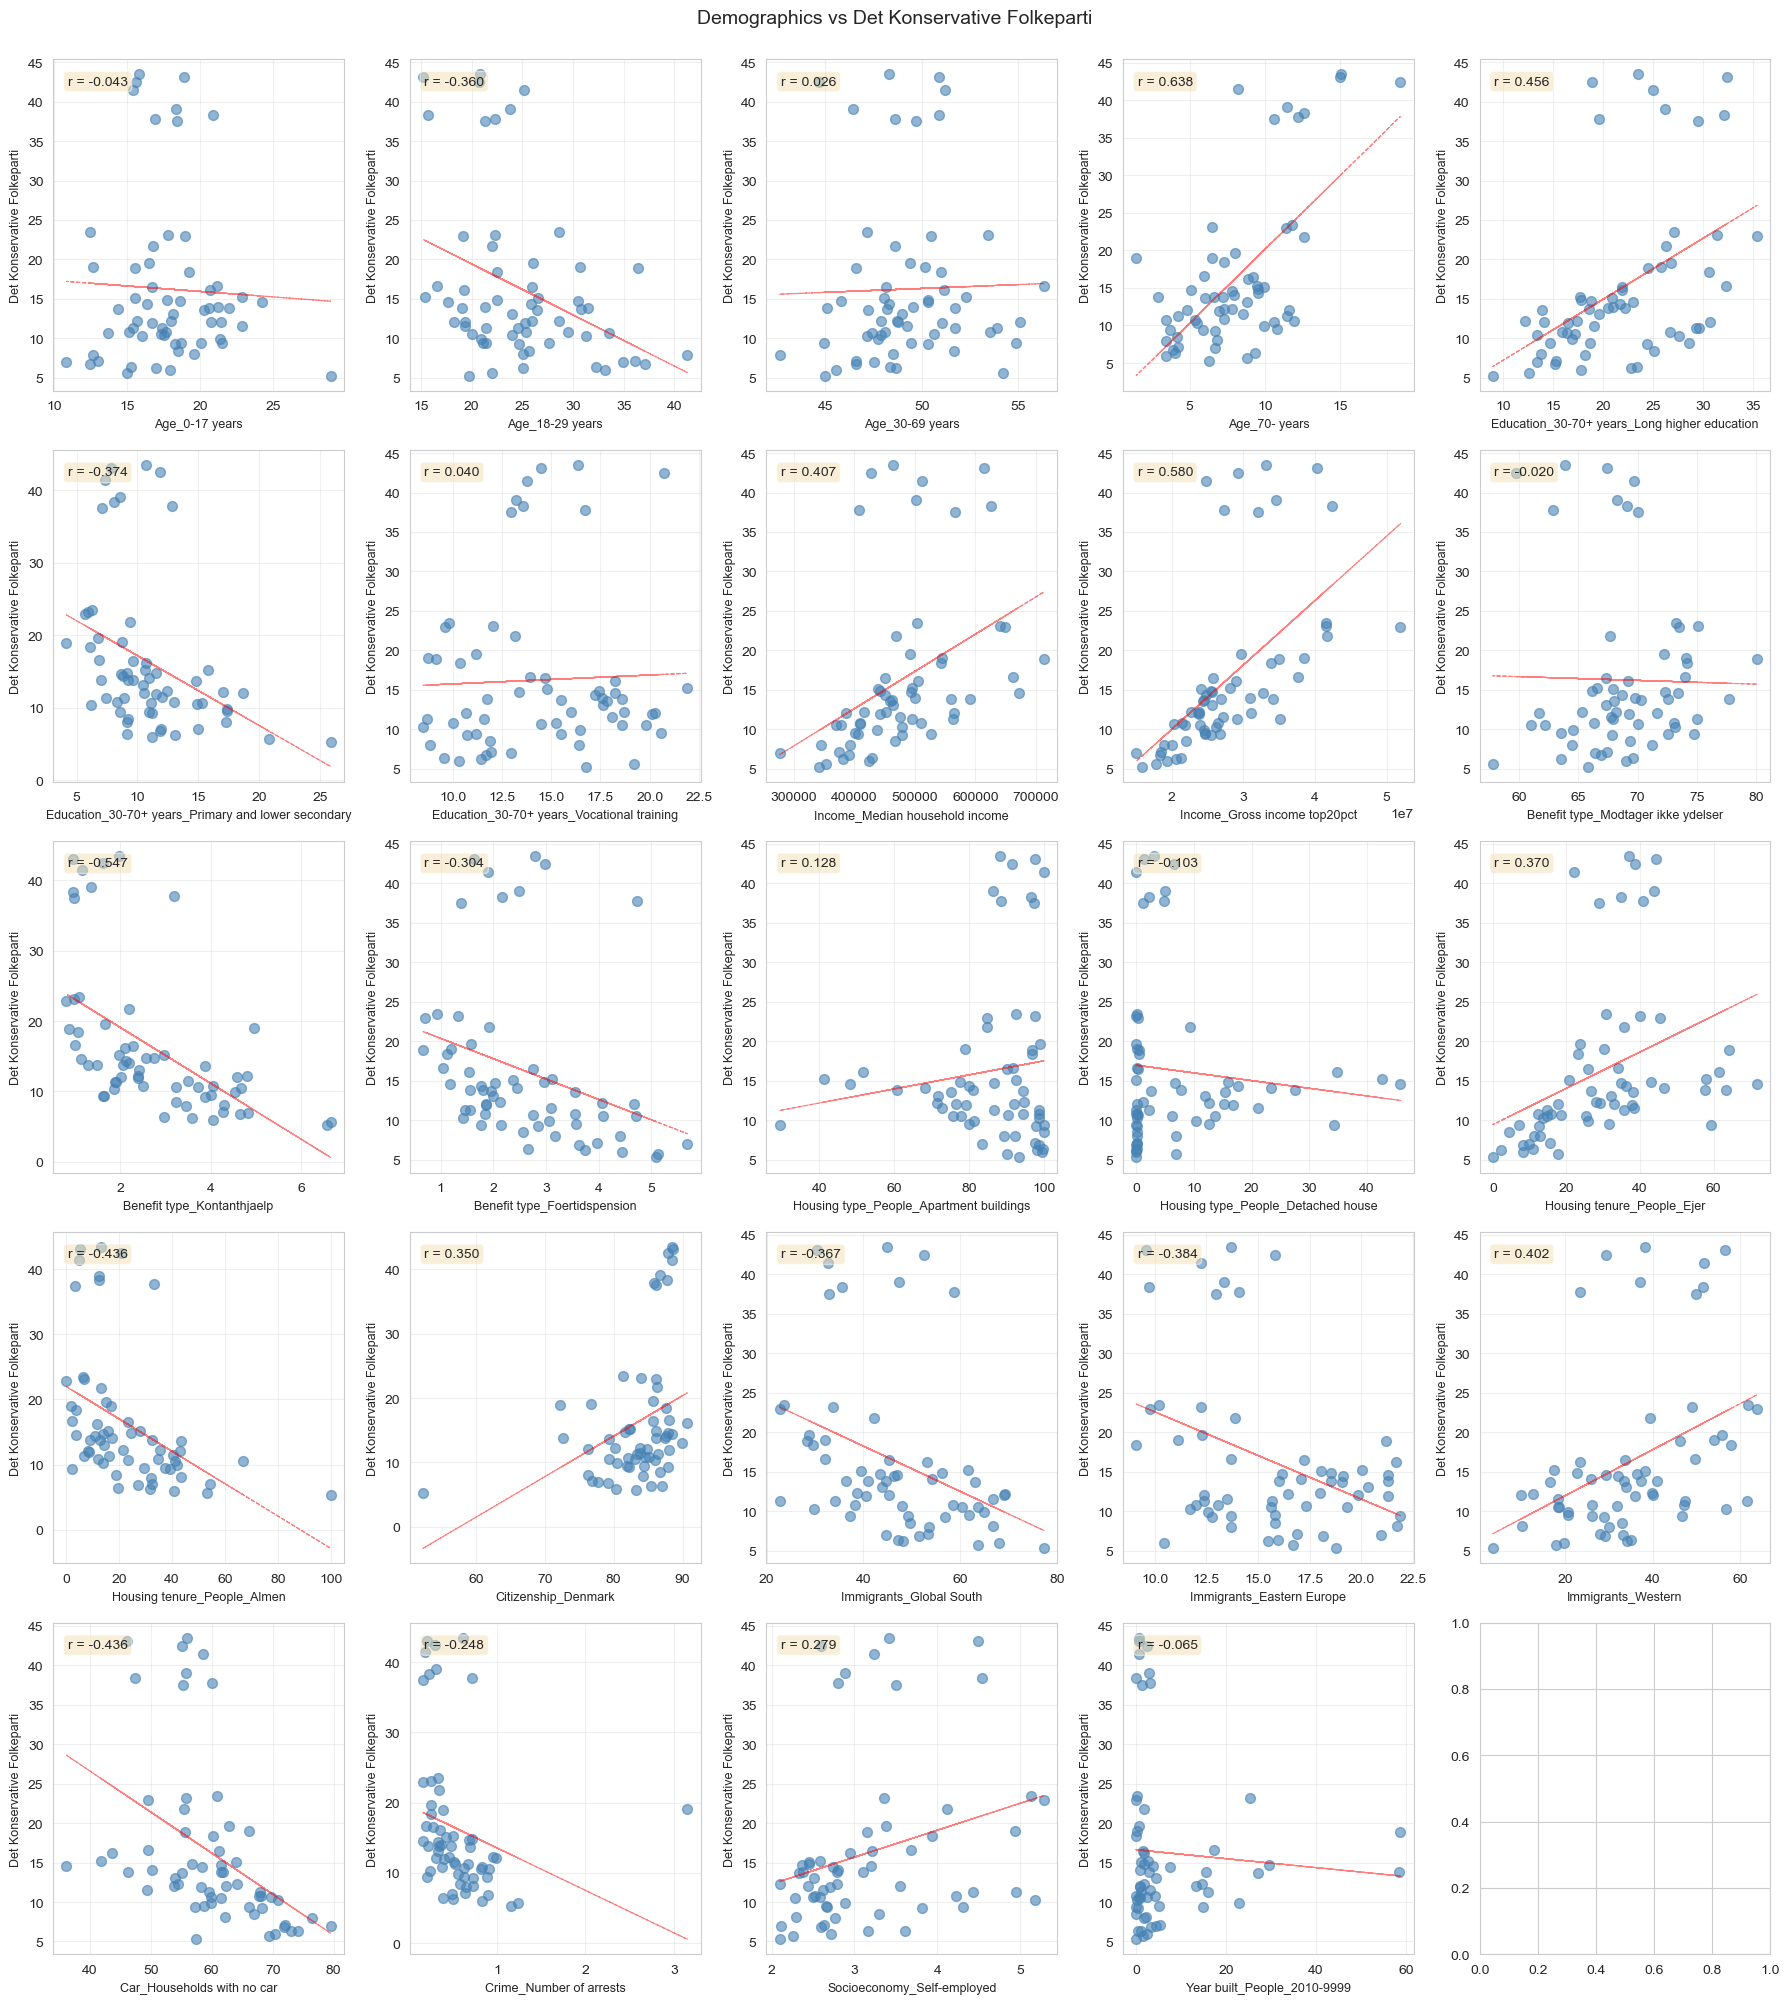

In [20]:
# Main demographics vs Konservative
party = 'Vote share_Det Konservative Folkeparti'

fig, axes = plt.subplots(5, 5, figsize=(18, 20))
axes = axes.flatten()

for idx, demo in enumerate(main_demographics):
    axes[idx].scatter(df_num[demo], df_num[party], alpha=0.6, s=50, color='steelblue')
    axes[idx].set_xlabel(demo, fontsize=9)
    axes[idx].set_ylabel(party.replace('Vote share_', ''), fontsize=9)
    axes[idx].grid(alpha=0.3)
    
    # Trend line
    z = np.polyfit(df_num[demo], df_num[party], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_num[demo], p(df_num[demo]), "r--", alpha=0.5, linewidth=0.8)
    
    # Correlation
    corr = df_num[[demo, party]].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Demographics vs {party.replace("Vote share_", "")}', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## t-SNE

### Remove voting data

We want to do the clustering without the voting data, because as we found out during some of the first tries at clustering, the voting data is a clear divisor between the Frederiksberg polling areas and the Copenhagen polling areas.

The hypothesis is that the voting data puts all Frederiksberg polling areas in their own cluster, because this data alone is so different - and that would take away our possibility of seeing how similar or different the Frederiksberg areas are from other Copenhagen areas on demographic and socioeconomic features.

But why is the voting data so different between Frederiksberg and Copenhagen? First of all, because the data is for different elections - yes, the election year is the same, but it is two different municipalities, so two different municipal elections. The local issues that are important for voters may be different, the candidates that you can vote for are different, and some parties may even be different. It would be completely different if we were using data from a national election - that would make voting data much more comparable across municipality borders.

With that in mind, it's not so strange that the Frederiksberg polling areas are all put in the same cluster. And we want to see the effects outside of the voting.

We will however keep the voter turnout.

In [21]:
demo_only = df_num.copy()
voting_cols = [col for col in demo_only.columns if col.startswith('Vote share_')]
demo_only = demo_only.drop(columns=voting_cols)
print(demo_only.columns.tolist())

['Sex_Female', 'Age_70- years', 'Age_0-17 years', 'Age_18-29 years', 'Age_30-69 years', 'Education_18-29 years_Long higher education', 'Education_18-29 years_Primary and lower secondary', 'Education_18-29 years_Vocational training', 'Education_30-70+ years_Long higher education', 'Education_30-70+ years_Primary and lower secondary', 'Education_30-70+ years_Vocational training', 'Income_Gross income top20pct', 'Income_Median household income', 'Socioeconomy_Self-employed', 'Socioeconomy_Top executives', 'Socioeconomy_Unemployed', 'Benefit type_Foertidspension', 'Benefit type_Kontanthjaelp', 'Benefit type_Modtager ikke ydelser', 'Housing type_People_Apartment buildings', 'Housing type_People_Detached house', 'Housing type_People_Terraced house', 'Housing tenure_People_Almen', 'Housing tenure_People_Andel', 'Housing tenure_People_Ejer', 'Housing tenure_People_Private rental', 'Year built_People_1960-2009', 'Year built_People_2010-9999', 'Year built_People_Before 1960', 'Car_Households wit

### Using t-SNE visualisations for EDA

Beware! This is before standardisation

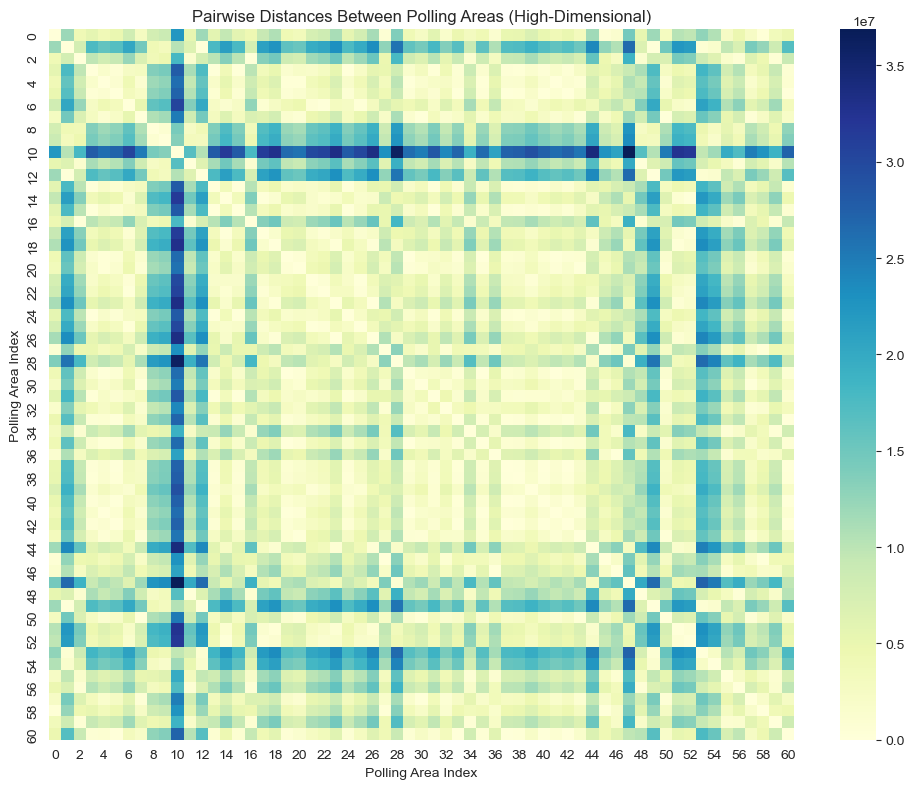

In [22]:
colors = [
    "#C03B26", # Red
    "#179E86", # Dark Green
    "#44546A", # Gray
]
# Calculate pairwise distances
df_dist = demo_only.copy()
pairwise_dist = pairwise_distances(df_dist, metric="euclidean")

plt.figure(figsize=(10, 8))
sns.heatmap(pairwise_dist, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Pairwise Distances Between Polling Areas (High-Dimensional)")
plt.xlabel("Polling Area Index")
plt.ylabel("Polling Area Index")
plt.tight_layout()
plt.show()

The heatmap tells us: considering all variables at once, how different are polling area i and polling area j? Higher/darker means more different, lower/lighter means more similar

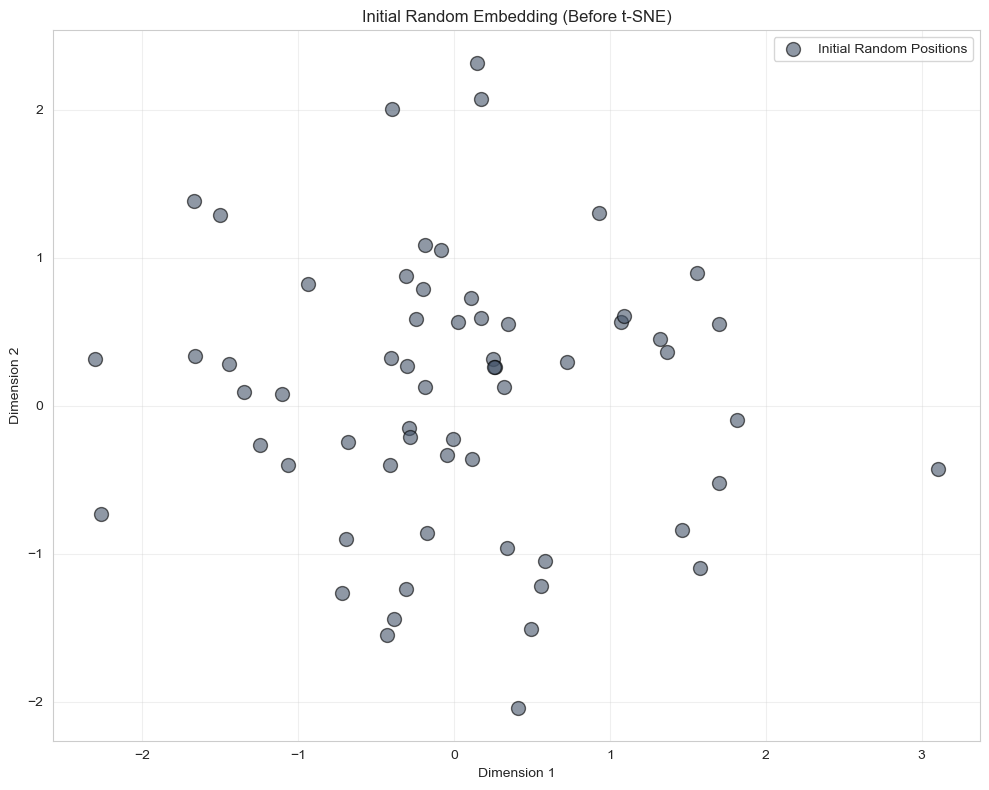

In [23]:
# Initial random low-dimensional embedding before optimization
initial_positions = np.random.randn(df_dist.shape[0], 2)
plt.figure(figsize=(10, 8))
plt.scatter(
    initial_positions[:, 0], initial_positions[:, 1],
    color=colors[-1], s=100, edgecolor='black', alpha=0.6,
    label="Initial Random Positions"
)
plt.title("Initial Random Embedding (Before t-SNE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

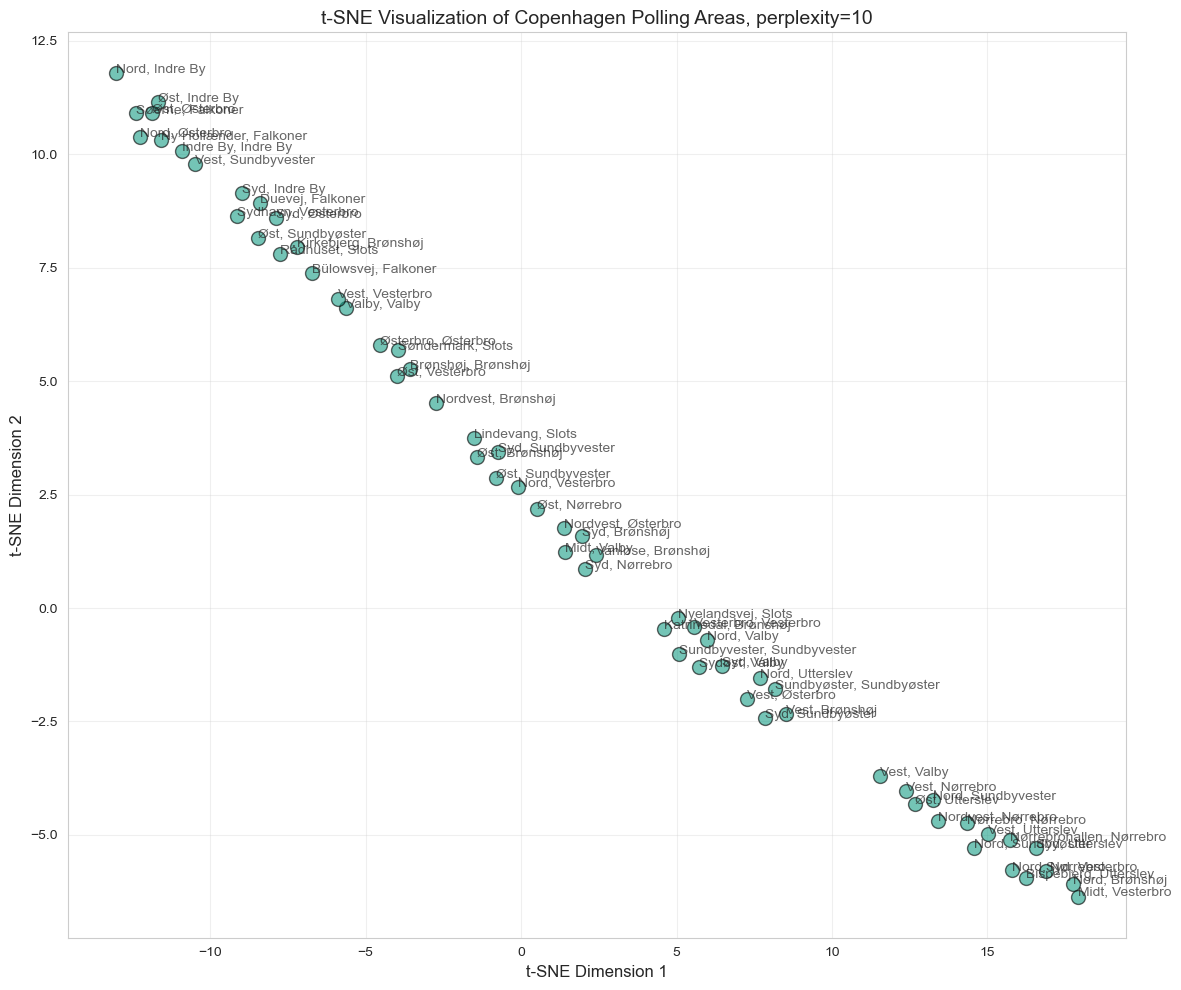

In [24]:
# Apply t-SNE to create a low-dimensional embedding
tsne = TSNE(
    n_components=2,
    perplexity=10, # intepreting perplexity as expected number of neighbours
    random_state=42
)

X_embedded = tsne.fit_transform(df_dist)

# Create df with t-SNE results
df_embedded = pd.DataFrame(
    X_embedded, 
    columns=["t-SNE Dimension 1", "t-SNE Dimension 2"]
)

# Polling area names for labels
df_embedded['Area'] = polling_areas['PollingArea'].values

# Basic plot
plt.figure(figsize=(12, 10))
plt.scatter(
    df_embedded["t-SNE Dimension 1"], 
    df_embedded["t-SNE Dimension 2"],
    s=100, 
    edgecolor='black', 
    alpha=0.6,
    color=colors[1]
)
for idx, row in df_embedded.iterrows():
    plt.annotate(
        row['Area'], 
        (row["t-SNE Dimension 1"], row["t-SNE Dimension 2"]),
        fontsize=10, 
        alpha=0.7
    )
plt.title("t-SNE Visualization of Copenhagen Polling Areas, perplexity=10", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Interpretation: Similarity map-ish. If two polling areas are close together in the scatter plot, that means they have similar profiles across all our features.

**Thoughts when perplexity is set to 10:**

We can see that some polling areas cluster together, but the clusters aren't that obvious.

**Thoughts when perplexity is set to 10, for a previous run with more features (less preprocessing):**
Frederiksberg is a more obvious cluster here.

So is a cluster with polling areas that I know have a lot of social housing (almene boliger) and immigrants: 8. Syd (Folehaven), 8. Sydøst (Sjælør Boulevard, but also expensive villa areas in Valby syd), 2. Sundbyvester (parts of Urbanplanen), 9. Syd (Old Sydhavn), 7. Nord (Tingbjerg), 8. Vest (Vigerslev), 7. Vest (parts of Voldparken, Tingbjerg), 6. Nord (Emdrup, also mixed villas and social housing), 6. Øst (also Emdrup, Ryparken), 6.Vest (around Rentemestervej).

Nørrebro polling areas are still close together here.

Polling areas in the districts Østerbro and Indre by (central city) are also close together.

There also seems to be a cluster with the hip areas of Vesterbro, together with one hip polling area of inner Nørrebro (5. Øst).

Polling areas 2. Syd (Ørestad) and 9. Sydhavn (Sluseholmen, Teglholmen, Frederiks Brygge) are still very close, and still seem quite isolated from the rest.

And 7. Katrinedal (central Vanløse) and 4. Syd (south Sundbyøster) are both more suburban polling areas with more villas and some partments, these are also shown as being close together but isolated from the rest.


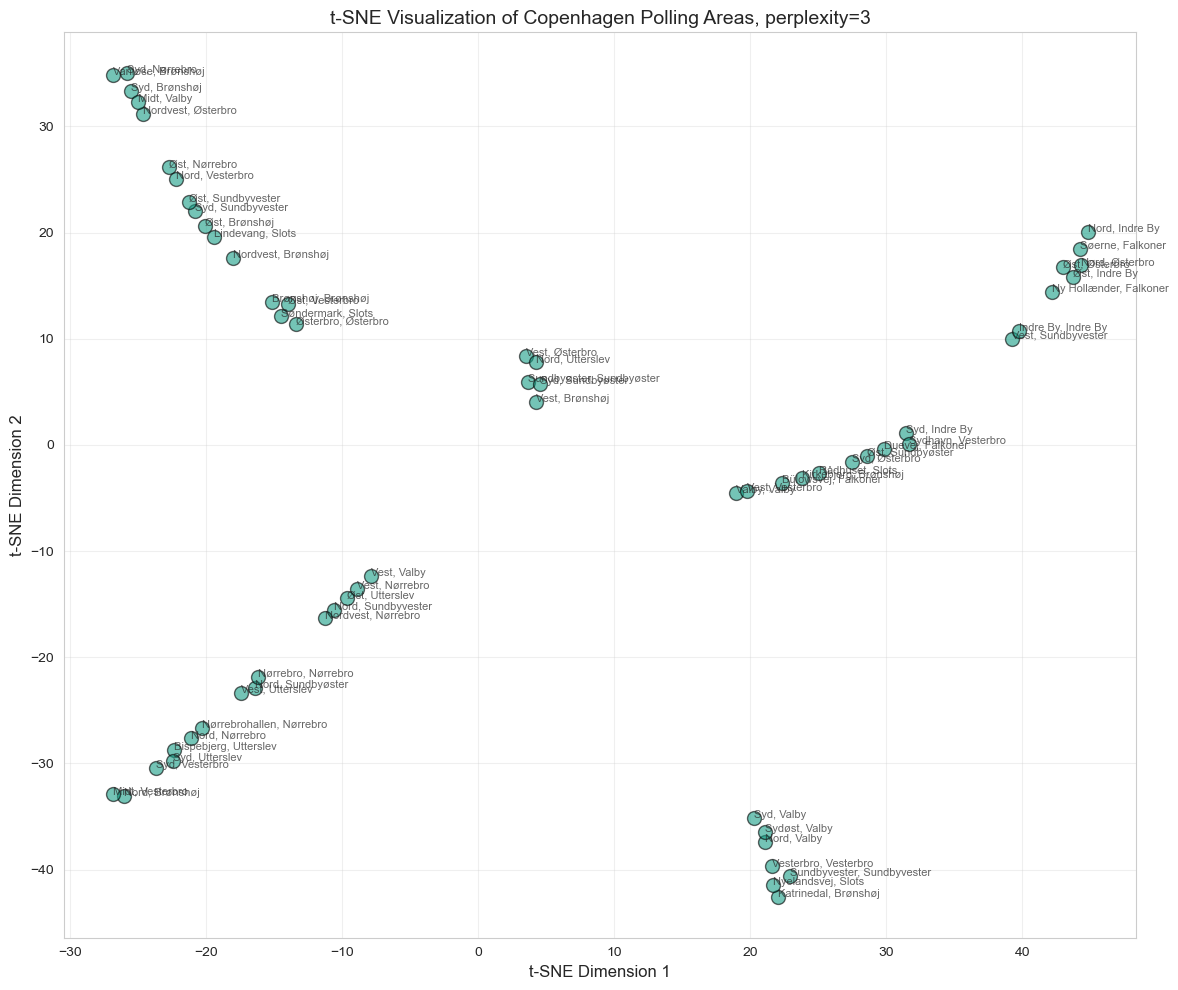

In [25]:
# Apply t-SNE to create a low-dimensional embedding
perplexity = 3
tsne = TSNE(
    n_components=2,
    perplexity=perplexity, # intepreting perplexity as expected number of neighbours
    random_state=42
)

X_embedded = tsne.fit_transform(df_dist)

# Create df with t-SNE results
df_embedded = pd.DataFrame(
    X_embedded, 
    columns=["t-SNE Dimension 1", "t-SNE Dimension 2"]
)

# Polling area names for labels
df_embedded['Area'] = polling_areas['PollingArea'].values

# Basic plot
plt.figure(figsize=(12, 10))
plt.scatter(
    df_embedded["t-SNE Dimension 1"], 
    df_embedded["t-SNE Dimension 2"],
    s=100, 
    edgecolor='black', 
    alpha=0.6,
    color=colors[1]
)
for idx, row in df_embedded.iterrows():
    plt.annotate(
        row['Area'], 
        (row["t-SNE Dimension 1"], row["t-SNE Dimension 2"]),
        fontsize=8, 
        alpha=0.7
    )
plt.title(f"t-SNE Visualization of Copenhagen Polling Areas, perplexity={perplexity}", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Thoughts when perplexity is set to 3:**

Clusters are more obvious and separated. Tingbjerg (Nord, Brønshøj) is more isolated, but together with Midt, Vesterbro.


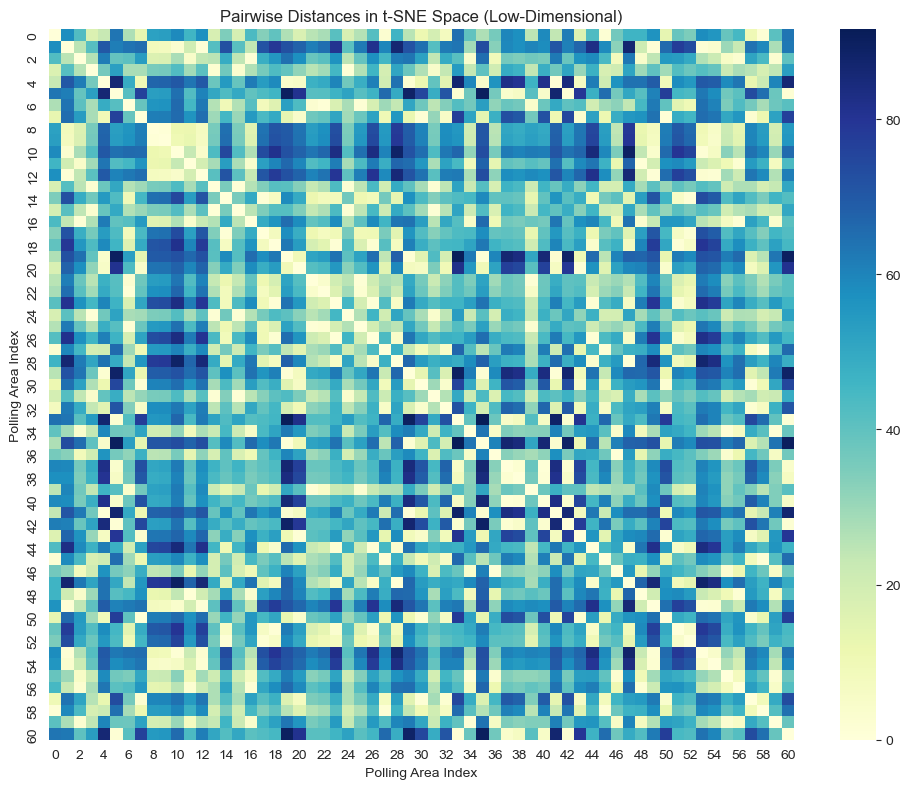

In [26]:
# Calculate pairwise distances in the t-SNE space
pairwise_dist_low_dim = pairwise_distances(X_embedded, metric="euclidean")

# Plot pairwise distances in low-dimensional space
plt.figure(figsize=(10, 8))
sns.heatmap(pairwise_dist_low_dim, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Pairwise Distances in t-SNE Space (Low-Dimensional)")
plt.xlabel("Polling Area Index")
plt.ylabel("Polling Area Index")
plt.tight_layout()
plt.show()

## Save to CSV

In [27]:
result_df = pd.concat([polling_areas, demo_only], axis=1)
result_df.to_csv(OUTPUT_PATH, index=False)
result_df

,PollingAreaID,PollingArea,Sex_Female,Age_70- years,Age_0-17 years,Age_18-29 years,Age_30-69 years,Education_18-29 years_Long higher education,Education_18-29 years_Primary and lower secondary,Education_18-29 years_Vocational training,Education_30-70+ years_Long higher education,Education_30-70+ years_Primary and lower secondary,Education_30-70+ years_Vocational training,Income_Gross income top20pct,Income_Median household income,Socioeconomy_Self-employed,Socioeconomy_Top executives,Socioeconomy_Unemployed,Benefit type_Foertidspension,Benefit type_Kontanthjaelp,Benefit type_Modtager ikke ydelser,Housing type_People_Apartment buildings,Housing type_People_Detached house,Housing type_People_Terraced house,Housing tenure_People_Almen,Housing tenure_People_Andel,Housing tenure_People_Ejer,Housing tenure_People_Private rental,Year built_People_1960-2009,Year built_People_2010-9999,Year built_People_Before 1960,Car_Households with no car,Crime_Number of arrests,Immigrants_Other Europe,Immigrants_Western,Immigrants_Eastern Europe,Immigrants_Global South,Citizenship_Denmark,Citizenship_Other Europe,Citizenship_Western,Citizenship_Eastern Europe,Citizenship_Global South,Voter turnout
0,101001,"Østerbro, Østerbro",52.891659,8.051664,16.533865,26.018507,49.395965,10.987579,3.473394,1.387824,26.813372,6.785769,11.156264,2.969178e+07,491202,3.383580,2.231998,2.354920,1.567922,1.664310,72.201517,98.791929,0.051407,0.912479,14.888967,47.997902,23.771638,13.341493,13.205244,0.578332,86.216425,62.854301,0.257036,3.052376,55.913978,12.313562,28.685397,85.728056,0.295592,9.812363,1.548644,2.563938,66.783831
1,101002,"Nord, Østerbro",53.354022,12.628312,16.782048,21.986154,48.603485,8.264108,3.566313,1.704383,26.267545,9.352621,13.162418,4.167502e+07,469505,4.112808,2.573443,2.479436,1.909764,2.196228,67.665314,84.829315,9.369778,3.174982,13.082514,41.798489,35.670514,9.448482,14.740988,1.778467,83.480544,55.478018,0.346145,4.627404,39.302885,13.882212,42.187500,86.345190,0.489377,7.495822,1.587491,4.010504,65.665549
2,101003,"Syd, Østerbro",51.785940,7.282595,19.222517,22.523034,50.971854,9.400109,3.487011,1.138934,30.657618,6.076917,10.367423,3.380967e+07,542786,3.939106,2.543609,2.581668,1.117001,1.072826,74.138584,96.655307,0.498549,0.145147,3.477405,62.437464,23.242844,10.842287,5.704910,0.000000,94.295090,60.194047,0.258740,3.316021,57.970435,9.109069,29.564523,87.656191,0.290294,8.696201,1.022340,2.328663,72.728727
3,101005,"Vest, Østerbro",51.759808,9.915479,15.529204,26.510660,48.044657,9.414039,3.256990,1.635931,20.925045,10.581499,14.782867,2.405004e+07,438719,2.453323,1.440133,2.708214,2.371641,1.980573,67.913460,92.449855,0.031538,3.355620,15.748988,54.923077,20.647773,8.680162,24.429166,1.078592,74.492242,64.004298,0.428914,4.205726,38.256904,18.039017,39.422346,82.408225,0.599218,8.981960,2.712249,5.279425,59.005636
4,101006,"Nordvest, Østerbro",51.605249,9.186624,16.690146,25.950916,48.172314,9.909349,4.257021,2.079630,21.916104,9.660505,14.664060,2.574739e+07,449840,3.214078,1.847004,2.785049,2.758212,2.276266,67.368577,90.086750,0.318826,8.408097,23.387463,40.669509,25.809671,10.133358,24.023133,1.623786,74.353081,61.210415,0.281753,3.877752,33.552415,17.252711,45.317121,85.719582,0.496775,6.977089,2.476459,4.255950,63.135707
5,101007,"Sundbyvester, Sundbyvester",51.139152,10.795654,18.703120,21.079565,49.421661,4.789437,5.505696,2.580255,14.756645,17.371419,20.555747,2.472034e+07,401150,2.653177,1.443328,3.162587,3.575184,4.009814,63.547143,79.817736,12.646337,7.115317,37.441860,24.550388,31.496124,6.511628,36.866456,5.124430,58.009113,58.667229,0.883281,1.320559,20.662869,15.846712,61.885034,84.458465,0.161234,5.257624,2.986330,7.010165,53.549518
6,101008,"Nord, Sundbyvester",51.588610,7.305409,15.138522,29.479991,48.076077,10.154960,4.464626,2.495872,15.908802,12.974724,15.248317,2.148680e+07,408813,2.524567,1.341007,3.447527,3.545515,4.062225,66.336851,94.233729,0.093448,0.687115,34.799414,42.769559,12.281754,10.149274,31.1